In [1]:
import os
import glob
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq

import nilearn.image as nimg
from nilearn import datasets, plotting
from nilearn.decomposition import CanICA
from nilearn.image import concat_imgs, math_img, resample_to_img
from nilearn.maskers import NiftiMasker
from nilearn.masking import compute_epi_mask, compute_multi_epi_mask
from nilearn.plotting import (
    plot_prob_atlas,
    plot_stat_map,
    plot_roi,
    find_xyz_cut_coords,
    show,
)

from sklearn.exceptions import ConvergenceWarning
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,balanced_accuracy_score
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
    permutation_test_score,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

warnings.filterwarnings("ignore", message=".*converting a masked element to nan.*")
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, f1_score
from scipy.stats import ttest_1samp
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.compose import ColumnTransformer
from statsmodels.stats.multitest import multipletests


In [2]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install nibabel nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.2 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.1
    Uninstalling pip-26.1.1:
      Successfully uninstalled pip-26.1.1


# Import Data


In [3]:
DATA_DIR = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO"  # file

patterns = [
    os.path.join(DATA_DIR, "h_*_rs_4mm.nii.gz"),
    os.path.join(DATA_DIR, "p_*_rs_4mm.nii.gz"),
    os.path.join(DATA_DIR, "s_*_rs_4mm.nii.gz"),
]

files = []
for pat in patterns:
    files.extend(glob.glob(pat))

files = sorted(files)

print("N files:", len(files))
print("First 5:\n", "\n".join(files[:5]))


N files: 49
First 5:
 /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s06_rs_4mm.nii.gz
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s07_rs_4mm.nii.gz
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s08_rs_4mm.nii.gz
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s124_rs_4mm.nii.gz
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s126_rs_4mm.nii.gz


In [4]:
def get_dim4_tr(fpath):
    img = nib.load(fpath)
    shape = img.shape
    zooms = img.header.get_zooms()
    dim4 = shape[3] if len(shape) == 4 else None
    tr = zooms[3] if len(zooms) >= 4 else None
    return dim4, tr, shape, zooms

dim4_list = []
tr_list = []
bad_files = []

for f in files:
    dim4, tr, shape, zooms = get_dim4_tr(f)
    dim4_list.append(dim4)
    tr_list.append(tr)
    if len(shape) != 4:
        bad_files.append((f, shape))

print("Unique dim4:", Counter(dim4_list))
print("Unique TR (rounded):", Counter([None if t is None else round(float(t), 4) for t in tr_list]))

if bad_files:
    print("WARNING: non-4D files detected (showing up to 5):")
    for x in bad_files[:5]:
        print(x)


Unique dim4: Counter({220: 49})
Unique TR (rounded): Counter({1.0: 49})


In [ ]:
TR_TRUE = 2.2
FIX_DIR = os.path.join(DATA_DIR, "TR_fixed_2p2")
os.makedirs(FIX_DIR, exist_ok=True)

fixed_files = []

for f in files:
    img = nib.load(f)
    hdr = img.header.copy()

    zooms = list(hdr.get_zooms())  # (dx, dy, dz, tr)
    if len(zooms) < 4:
        raise RuntimeError(f"Not a 4D NIfTI? {f} zooms={zooms}")

    old_tr = float(zooms[3])
    zooms[3] = TR_TRUE
    hdr.set_zooms(tuple(zooms))

  
    out_path = os.path.join(FIX_DIR, os.path.basename(f))
    new_img = nib.Nifti1Image(img.dataobj, img.affine, hdr)
    new_img.to_filename(out_path)

    fixed_files.append(out_path)

print("Saved TR-fixed files:", len(fixed_files))
print("Output folder:", FIX_DIR)
print("Example file:", fixed_files[0])


Saved TR-fixed files: 49
Output folder: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/TR_fixed_2p2
Example file: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/TR_fixed_2p2/h_s06_rs_4mm.nii.gz


In [6]:
test_img = nib.load(fixed_files[0])
print("TR in header:", test_img.header.get_zooms()[3])

TR in header: 2.2


In [7]:
trs = []
for f in fixed_files:
    trs.append(round(float(nib.load(f).header.get_zooms()[3]), 4))

print("Unique TRs:", set(trs))

Unique TRs: {2.2}


# Group ICA

Firstly， PCA for each subject, changed to (220,20).


In [ ]:
N_COMPONENTS = 20
RANDOM_STATE = 42
n_jobs = max(1, (os.cpu_count() or 2) - 1)

OUT_DIR = os.path.join(DATA_DIR, "py_groupICA_20_commonmask")
os.makedirs(OUT_DIR, exist_ok=True)


common_mask_img = compute_multi_epi_mask(
    fixed_files,
    lower_cutoff=0.2,
    upper_cutoff=0.85,
    connected=True,
    opening=2,
    threshold=0.7,   
    # threshold=0.9
    target_affine=None,
    target_shape=None,
    memory=os.path.join(OUT_DIR, "nilearn_cache"),
    verbose=1,
)

common_mask_path = os.path.join(OUT_DIR, "common_epi_mask.nii.gz")
common_mask_img.to_filename(common_mask_path)
print("✅ common mask saved:", common_mask_path)



✅ common mask saved: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/py_groupICA_20_commonmask/common_epi_mask.nii.gz


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  49 out of  49 | elapsed:    0.2s finished


In [ ]:

import nibabel as nib

mask_img = nib.load(common_mask_path)
sample_data = nib.load(fixed_files[0])

print("Mask affine:\n", mask_img.affine)
print("Data affine:\n", sample_data.affine)
print("Mask shape:", mask_img.shape)
print("Data shape:", sample_data.shape[:3])

Mask affine:
 [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
Data affine:
 [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
Mask shape: (45, 54, 45)
Data shape: (45, 54, 45)


In [ ]:
canica_tut = CanICA(
    n_components=N_COMPONENTS,
    mask=common_mask_img,   
    memory=os.path.join(OUT_DIR, "nilearn_cache"),
    memory_level=2,
    verbose=0,
    random_state=RANDOM_STATE,
    standardize="zscore_sample",
    # mask_strategy="whole-brain-template", #mask
    n_jobs=n_jobs,
    smoothing_fwhm=None,
    n_init=10,
    threshold="auto",
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    canica_tut.fit(fixed_files) 

components_img_tut = canica_tut.components_img_  
components_path_tut = os.path.join(OUT_DIR, f"groupICA_canica_tutorial_{N_COMPONENTS}.nii.gz")
components_img_tut.to_filename(components_path_tut)

print("✅ TUTORIAL saved:", components_path_tut)
print("TUTORIAL shape:", components_img_tut.shape)
print("n_jobs:", n_jobs, "random_state:", RANDOM_STATE)

✅ TUTORIAL saved: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/py_groupICA_20_commonmask/groupICA_canica_tutorial_20.nii.gz
TUTORIAL shape: (45, 54, 45, 20)
n_jobs: 11 random_state: 42


In [11]:
shapes = []

for f in fixed_files:
    img = nib.load(f)
    shapes.append(img.shape[:3])  

print("Unique spatial shapes:", Counter(shapes))

Unique spatial shapes: Counter({(45, 54, 45): 49})


## Visualization

Good component (brain network):
  ✅ Spatially focal and localised
  ✅ Located in grey matter
  ✅ Bilateral symmetry (for most networks)
  ✅ Matches known resting-state networks

Noise component:
  ❌ Located in white matter or ventricles
  ❌ Located at brain edges (motion artifact)
  ❌ Spatially diffuse and scattered
  ❌ Located near large blood vessels

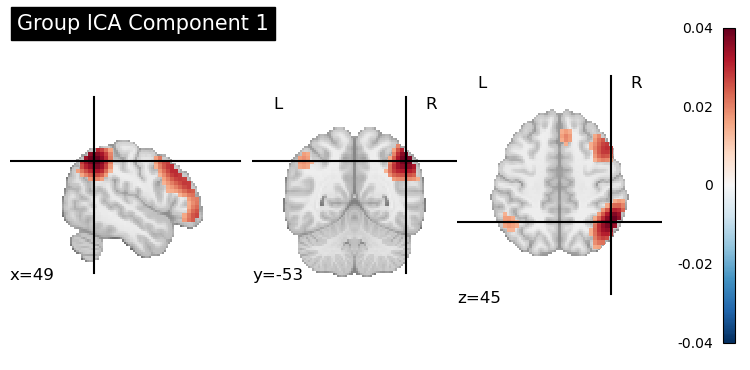

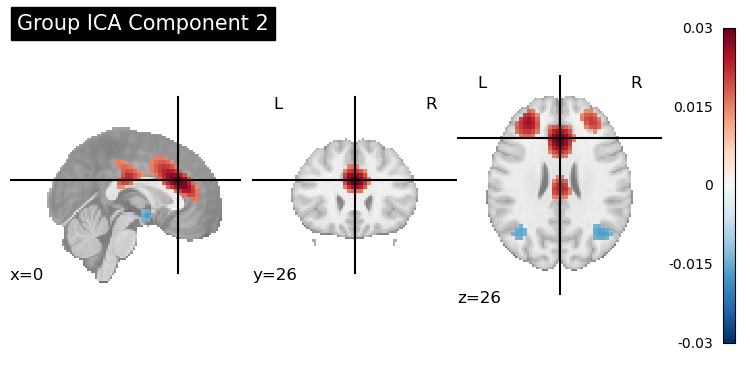

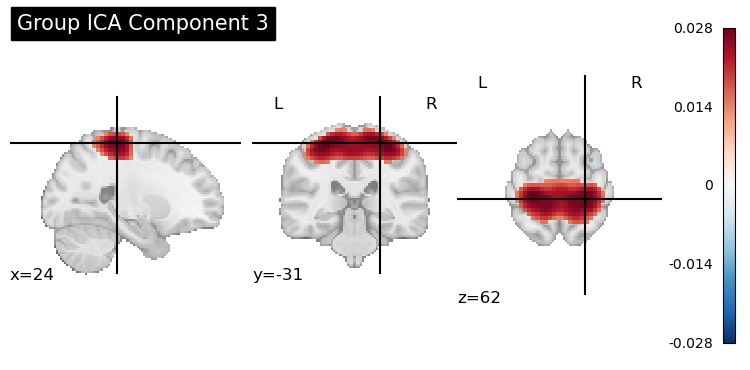

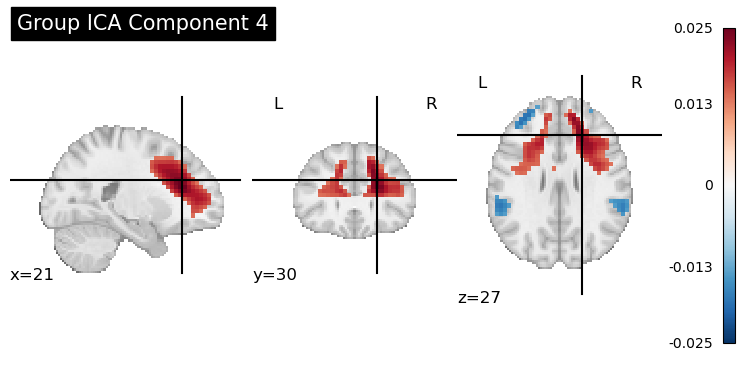

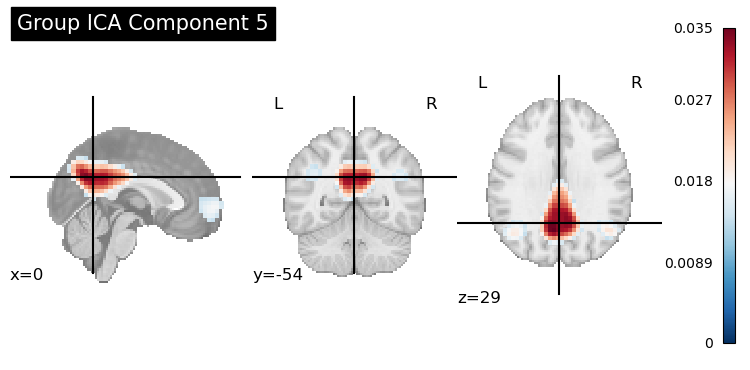

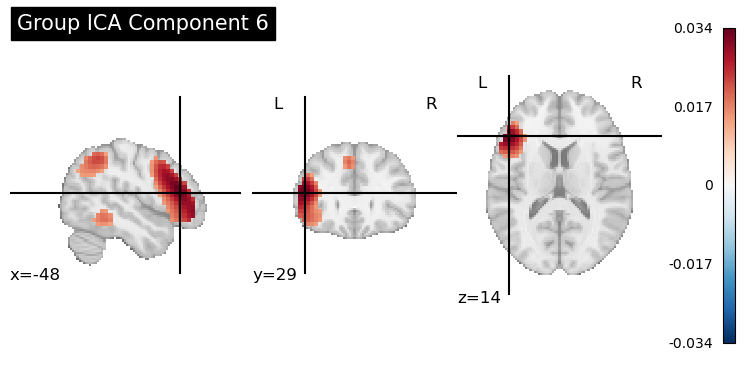

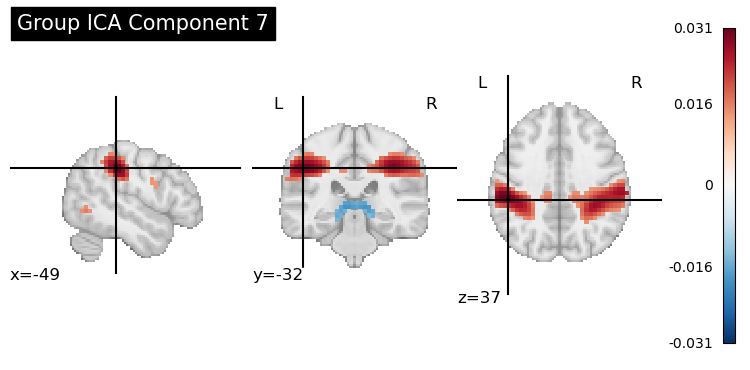

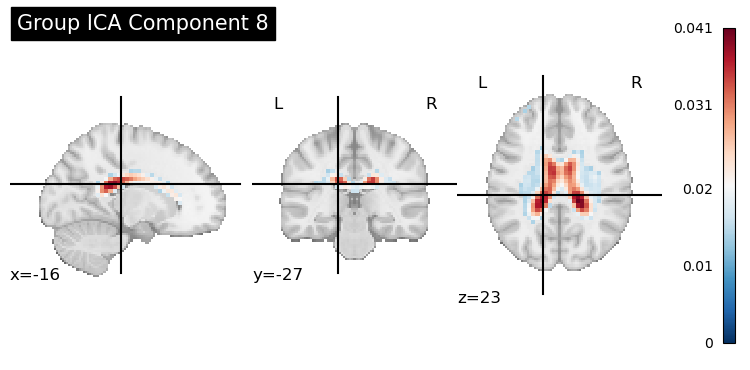

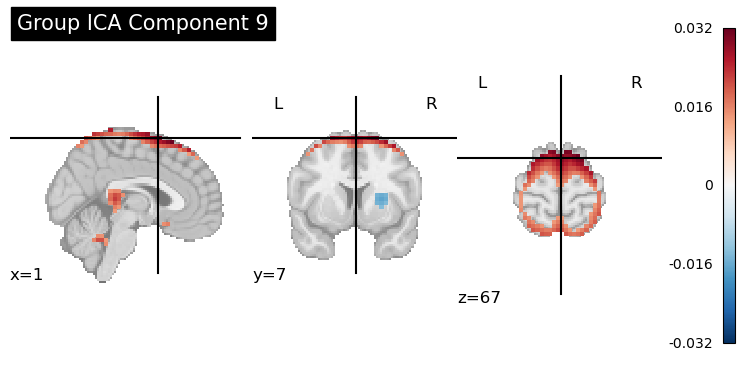

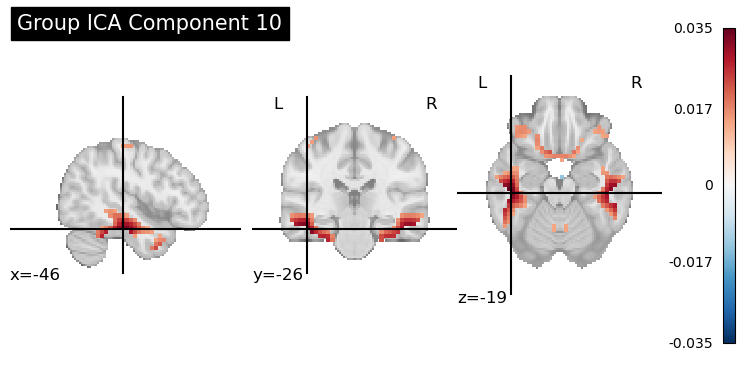

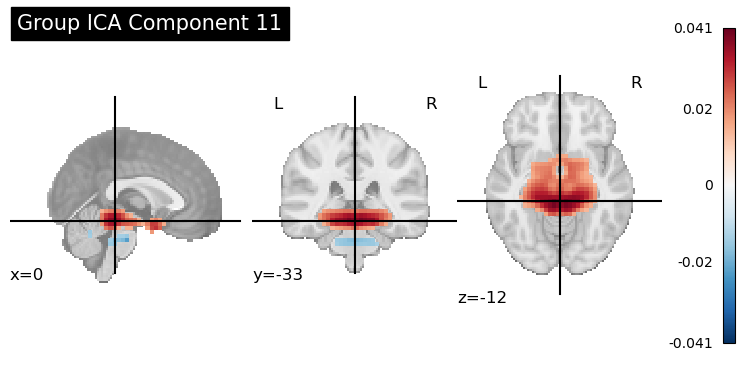

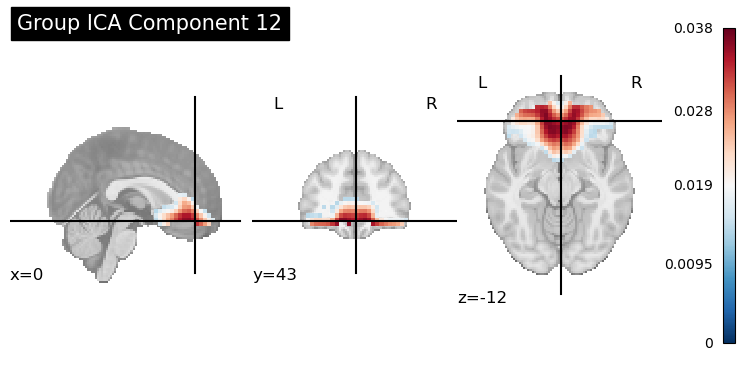

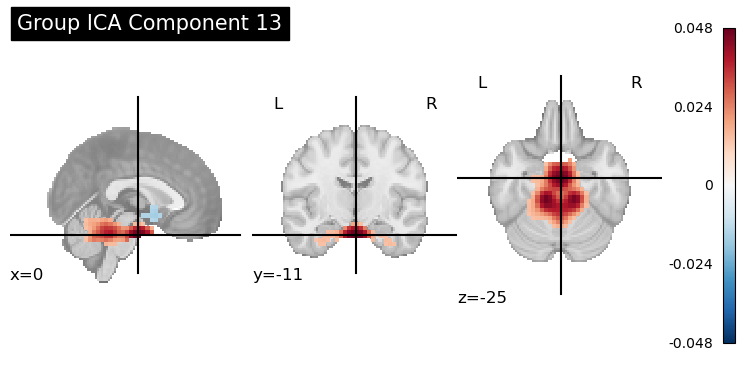

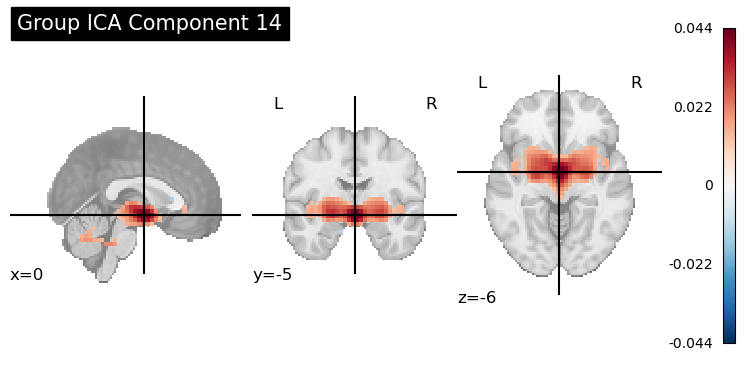

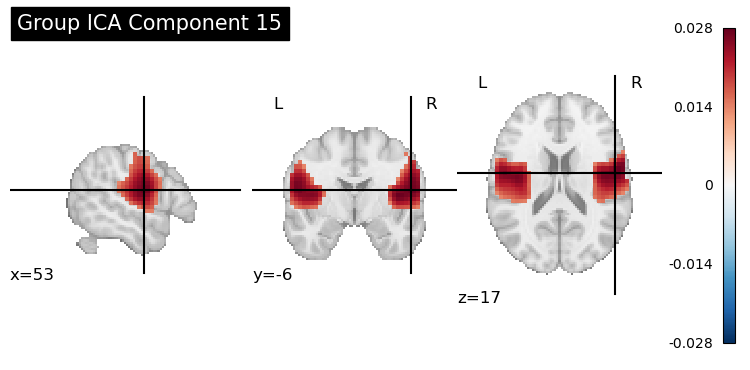

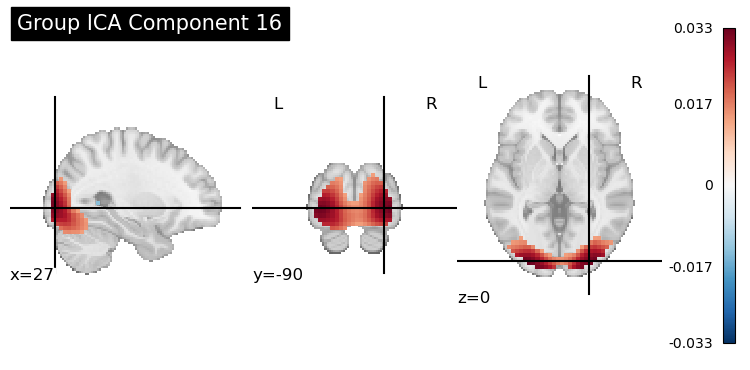

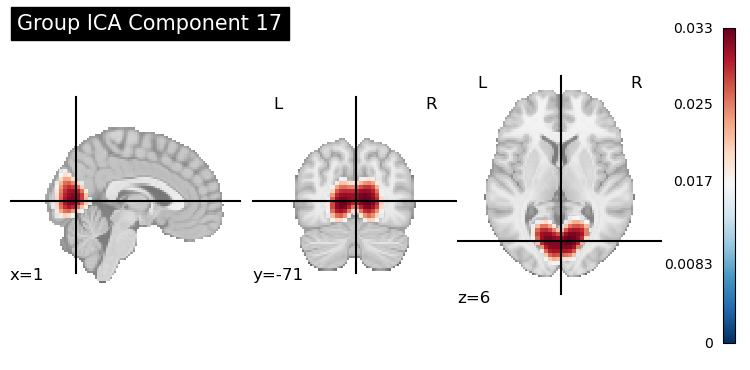

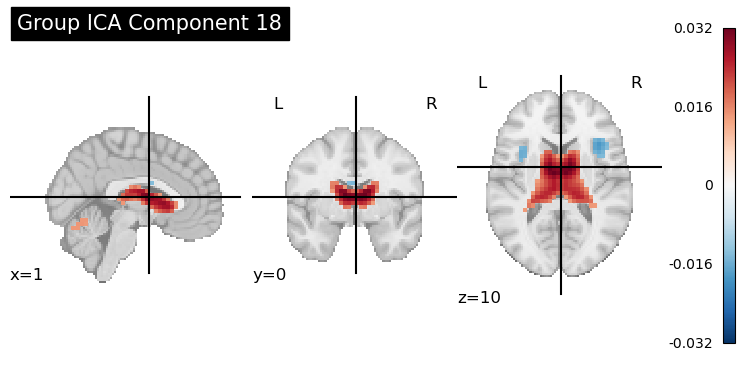

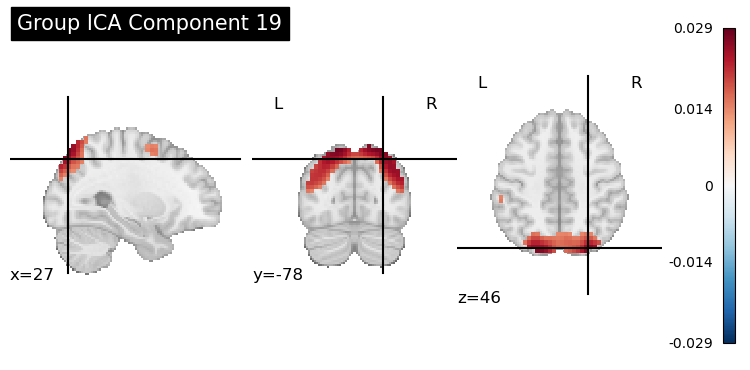

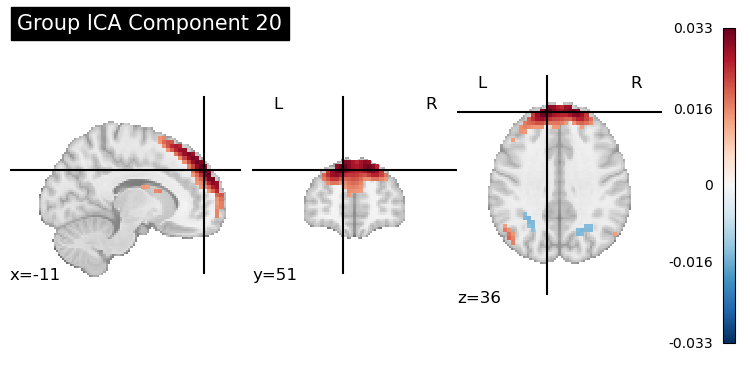

In [12]:
for k in range(N_COMPONENTS):
    comp_k = nimg.index_img(components_img_tut, k)
    coords = find_xyz_cut_coords(comp_k)
    plot_stat_map(comp_k, title=f"Group ICA Component {k+1}", 
                display_mode="ortho", 
                cut_coords=coords,
                # cut_coords=(0, 0, 0),
                # threshold=threshold,
                colorbar=True,
                black_bg=False)
show()

# Dual regression

## Spatial regression

In [ ]:
TR = 2.2
N_COMPONENTS = 20

OUT_STEP1 = os.path.join(OUT_DIR, "dualreg_step1_timecourses")
os.makedirs(OUT_STEP1, exist_ok=True)


mask_img = None
if hasattr(canica_tut, "mask_img_") and canica_tut.mask_img_ is not None:
    mask_img = canica_tut.mask_img_
elif hasattr(canica_tut, "masker_") and hasattr(canica_tut.masker_, "mask_img_"):
    mask_img = canica_tut.masker_.mask_img_
else:
    raise RuntimeError("找不到 canica_tut 的 mask_img_。请检查 CanICA 是否成功fit，或自己提供一个mask。")

masker = NiftiMasker(
    mask_img=mask_img,
    detrend=False,                
    standardize=False,            
    # standardize="zscore_sample",
    t_r=TR,
)

S = masker.fit_transform(components_img_tut)  


SS_T_inv = np.linalg.pinv(S @ S.T)   # (20×20)
S_pinv = S.T @ SS_T_inv              # (n_vox × 20)

print("✅ Spatial regressors matrix S shape:", S.shape)      # (20, n_vox)
print("✅ S_pinv shape:", S_pinv.shape)                      # (n_vox, 20)

# -------------------------

# do spatial regression for each subject，get 20 time courses (220*20)
# -------------------------
for f in fixed_files:
    subj_id = os.path.basename(f).replace(".nii.gz", "").replace(".nii", "")
    img = nib.load(f)

    # X: (220 × n_vox)
    X = masker.transform(img)

    # Dual reg step1: A = X @ S_pinv  -> (220 × 20)
    A = X @ S_pinv


    cols = [f"IC{str(i+1).zfill(2)}" for i in range(N_COMPONENTS)]
    df = pd.DataFrame(A, columns=cols)
    out_tsv = os.path.join(OUT_STEP1, f"{subj_id}_step1_timecourses.tsv")
    df.to_csv(out_tsv, sep="\t", index=False)

print(f"Done. Saved timecourses to: {OUT_STEP1}")

/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/2765959282.py:34: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  S = masker.fit_transform(components_img_tut)  # 这里返回 shape: (20, n_voxels),(20*109350)


✅ Spatial regressors matrix S shape: (20, 23305)
✅ S_pinv shape: (23305, 20)
Done. Saved timecourses to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/py_groupICA_20_commonmask/dualreg_step1_timecourses


In [14]:
# select one subject
file_path1 = os.path.join(OUT_STEP1, "h_s06_rs_4mm_step1_timecourses.tsv")
df1 = pd.read_csv(file_path1, sep="\t")

print(df1.shape)
print(df1.columns)
df1

(220, 20)
Index(['IC01', 'IC02', 'IC03', 'IC04', 'IC05', 'IC06', 'IC07', 'IC08', 'IC09',
       'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18',
       'IC19', 'IC20'],
      dtype='object')


,IC01,IC02,IC03,IC04,IC05,IC06,IC07,IC08,IC09,IC10,IC11,IC12,IC13,IC14,IC15,IC16,IC17,IC18,IC19,IC20
0,290336.50,336266.22,423763.12,356545.84,374100.28,328930.00,284987.38,428973.16,146354.25,369057.25,352068.60,278854.78,341471.20,445085.30,394219.20,378528.47,423322.97,303462.00,133474.08,325234.47
1,290072.44,336528.70,424580.34,356173.40,374768.20,329641.94,285225.25,428231.34,146177.11,368886.80,352042.47,278968.34,340475.03,446008.84,394472.30,379500.06,424158.88,303226.90,133715.50,325590.50
2,290700.28,337011.44,425747.60,356474.62,375782.22,329456.60,285439.25,429051.60,146648.05,368577.60,350772.06,278855.97,338579.28,444981.94,393101.75,380743.00,424313.60,303776.22,135630.66,327003.60
3,290056.25,336292.72,424852.62,356854.16,373665.70,328331.00,285552.88,429257.60,147099.03,367767.16,350415.34,278788.75,338250.30,444026.90,393021.50,380500.30,423138.38,303515.38,135811.39,326636.38
4,288770.94,334574.44,424163.78,356245.97,371557.28,327255.34,284846.60,429022.90,146971.16,368403.75,350554.60,278319.84,340320.62,443295.84,393112.25,379466.53,423165.47,302741.66,134578.16,324298.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,289737.90,332800.70,425517.72,355792.84,378534.16,329461.40,285302.60,429007.80,146507.31,371568.60,353278.22,280455.72,339892.03,443596.90,395940.30,383480.56,426559.80,301799.80,133115.69,325481.00
216,290243.25,335420.75,427366.84,357279.44,377678.84,330016.30,286604.56,428471.53,146711.25,371009.30,352555.60,279773.84,342252.10,443003.25,396846.30,384684.16,426536.66,302362.22,134618.47,328234.78
217,291188.88,336730.40,429101.10,357617.20,377513.78,331680.78,286427.12,429469.62,148087.83,371509.20,351775.62,279347.16,344825.44,443227.06,398333.70,385831.72,427276.53,302336.88,135871.28,329772.03
218,291924.40,335154.10,428974.90,356842.90,376090.22,330255.34,286004.40,429253.66,148016.23,370114.88,351147.03,279572.62,340934.80,445325.47,397364.34,385433.44,426917.80,302792.40,136330.60,326776.66


### Visualization of 20 time courses

The time course of subject i at time t for component k is obtained by projecting the subject’s voxel-wise BOLD signal onto the spatial map of that component.

The time course of subject i at time t for component k is computed as the weighted sum of voxel-wise BOLD signals, where the weights correspond to the spatial loadings of that component.

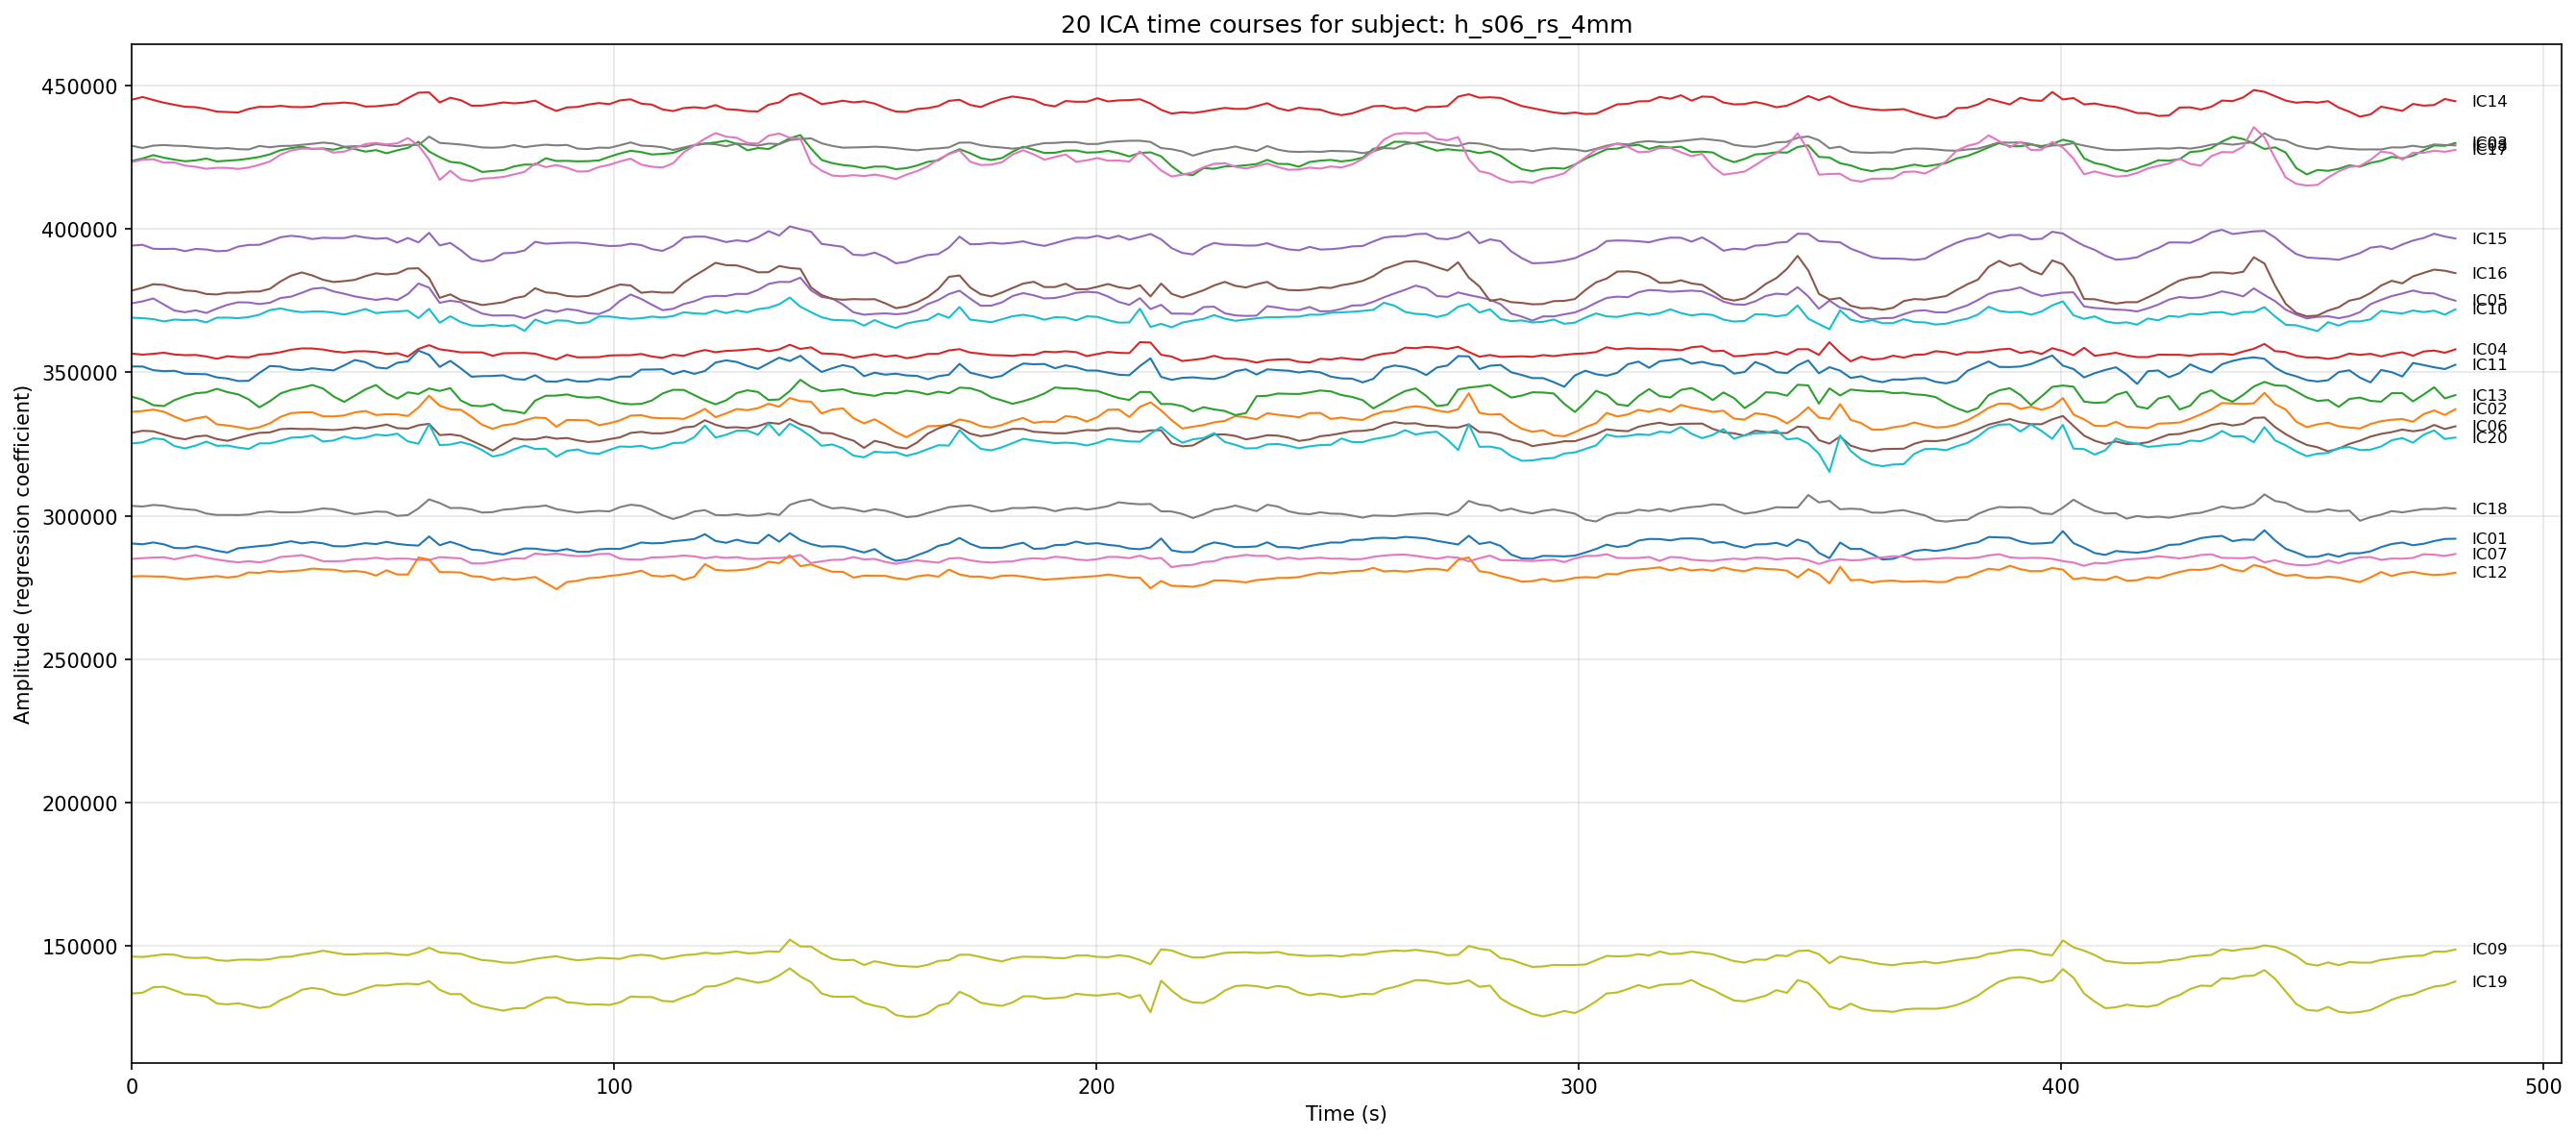

In [15]:
TR = 2.2  
t = np.arange(df1.shape[0]) * TR  # transfer time points to seconds
subj_id = os.path.basename(file_path1).replace("_step1_timecourses.tsv", "")


plt.figure(figsize=(18,8), dpi=150)
for col in df1.columns:
    y = df1[col].values
    plt.plot(t, y, linewidth=1)
    
    plt.text(t[-1] + TR*1.5, y[-1], col, fontsize=8, va="center")

# plt.title(f"Dual Regression Step 1: 20 ICA time courses ({subj_id})")
plt.title(f"20 ICA time courses for subject: {subj_id}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (regression coefficient)")
plt.grid(True, alpha=0.3)


plt.xlim(t[0], t[-1] + TR*10)
plt.tight_layout()
plt.show()

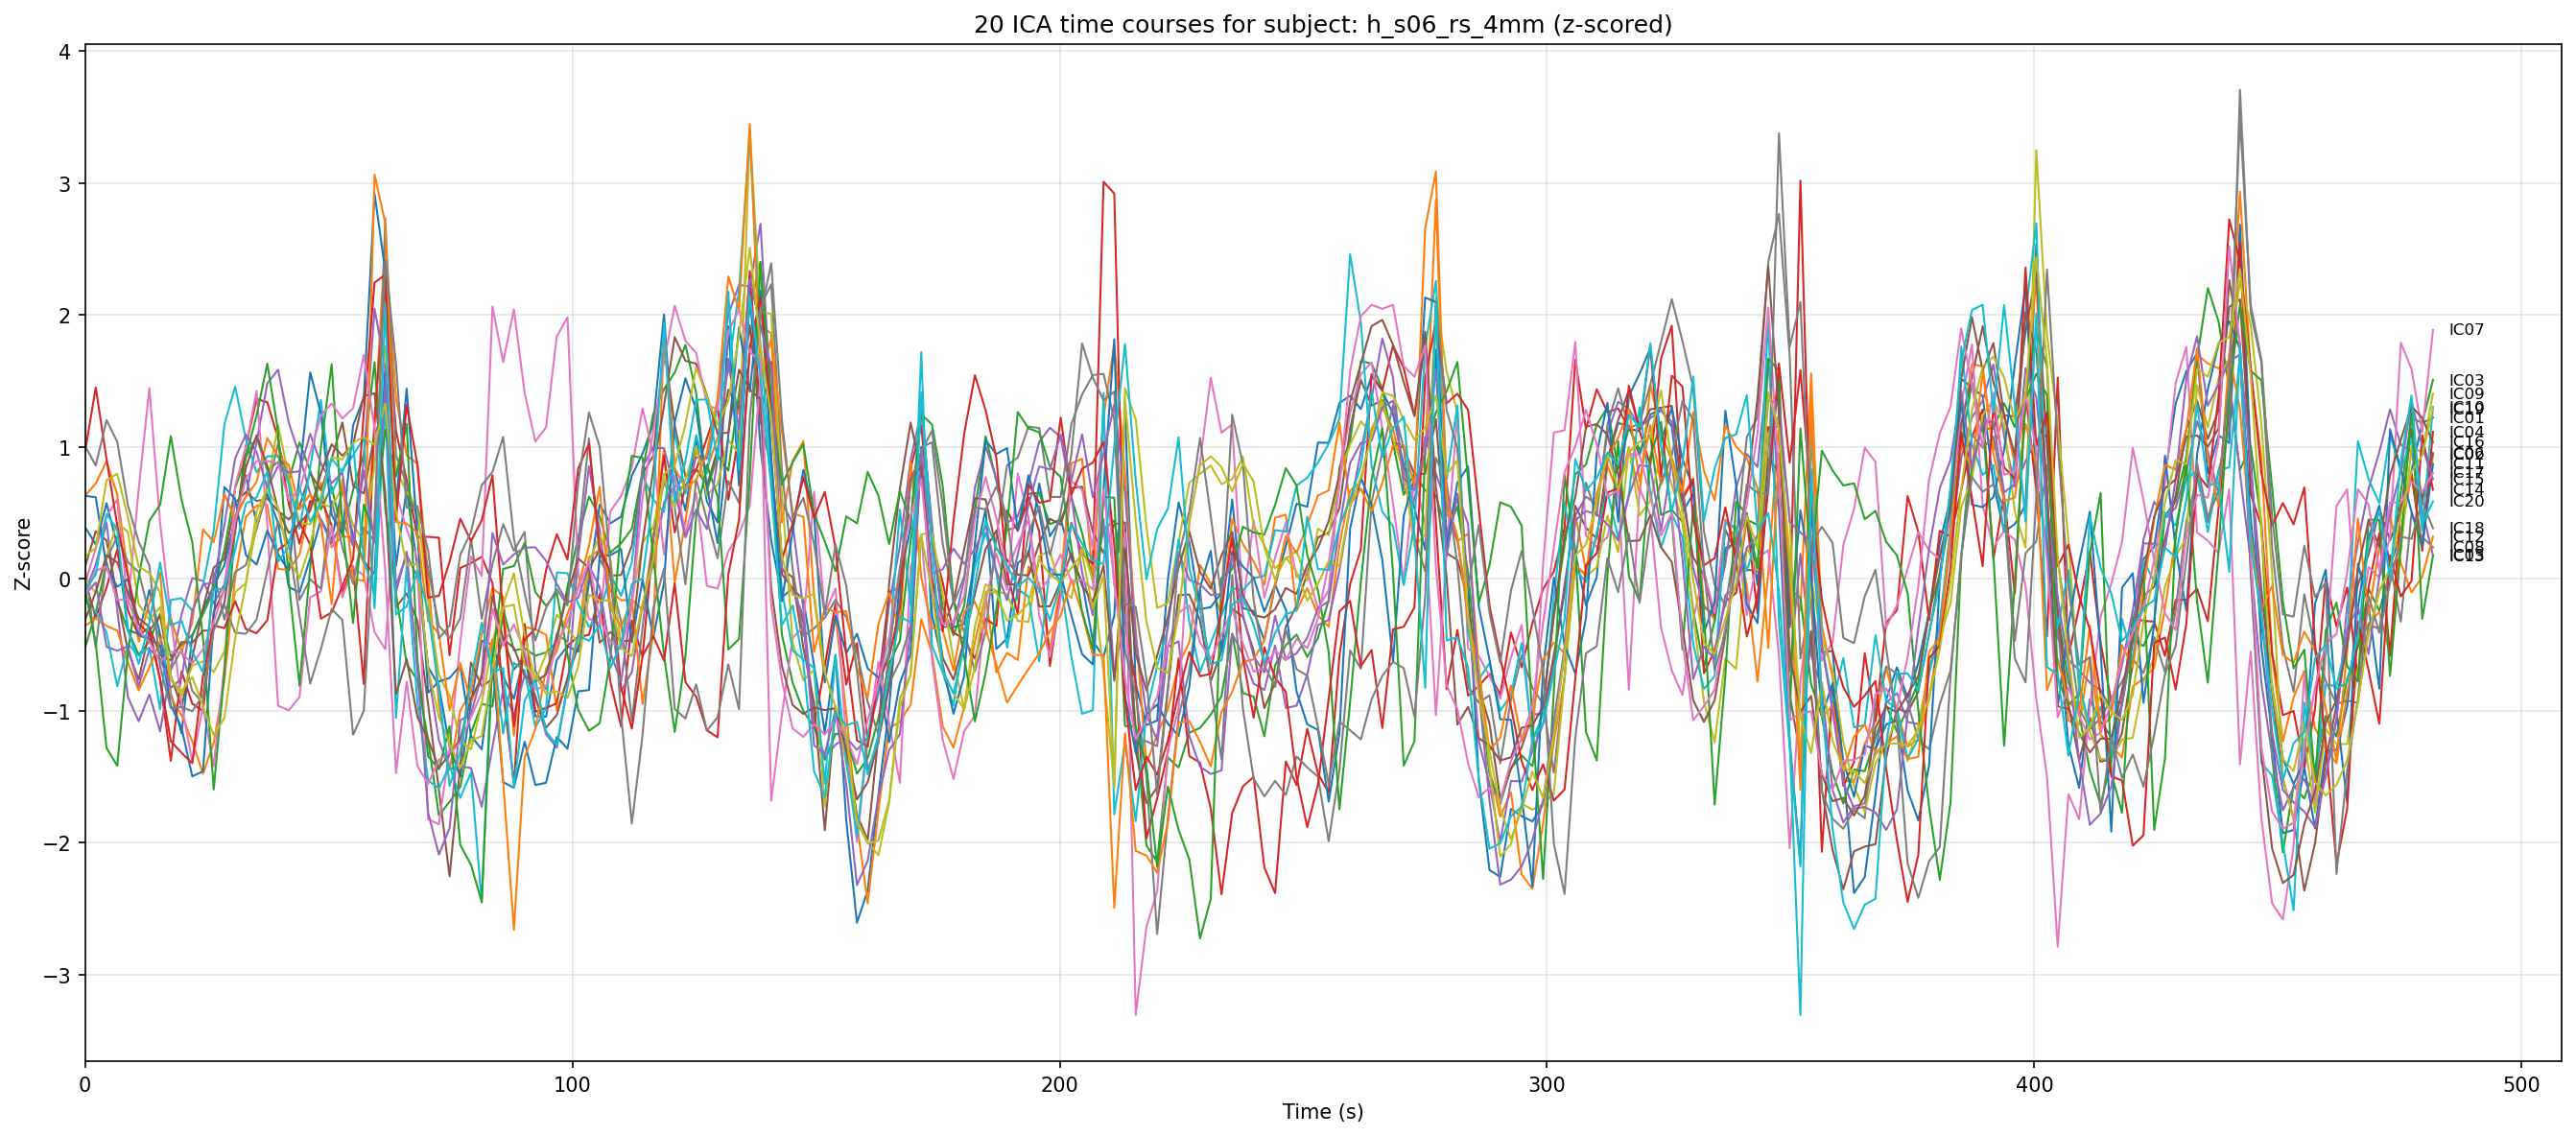

In [16]:
TR = 2.2
t = np.arange(df1.shape[0]) * TR  

df1_plot = (df1 - df1.mean()) / df1.std(ddof=0) # z-score
subj_id = os.path.basename(file_path1).replace("_step1_timecourses.tsv", "")

plt.figure(figsize=(18, 8), dpi=150)

for col in df1_plot.columns:
    y = df1_plot[col].values             
    plt.plot(t, y, linewidth=1)
    plt.text(t[-1] + TR*1.5, y[-1], col, fontsize=8, va="center")  

plt.title(f"20 ICA time courses for subject: {subj_id} (z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")
plt.grid(True, alpha=0.3)

plt.xlim(t[0], t[-1] + TR*12)  
plt.tight_layout()
plt.show()

### FC matrice


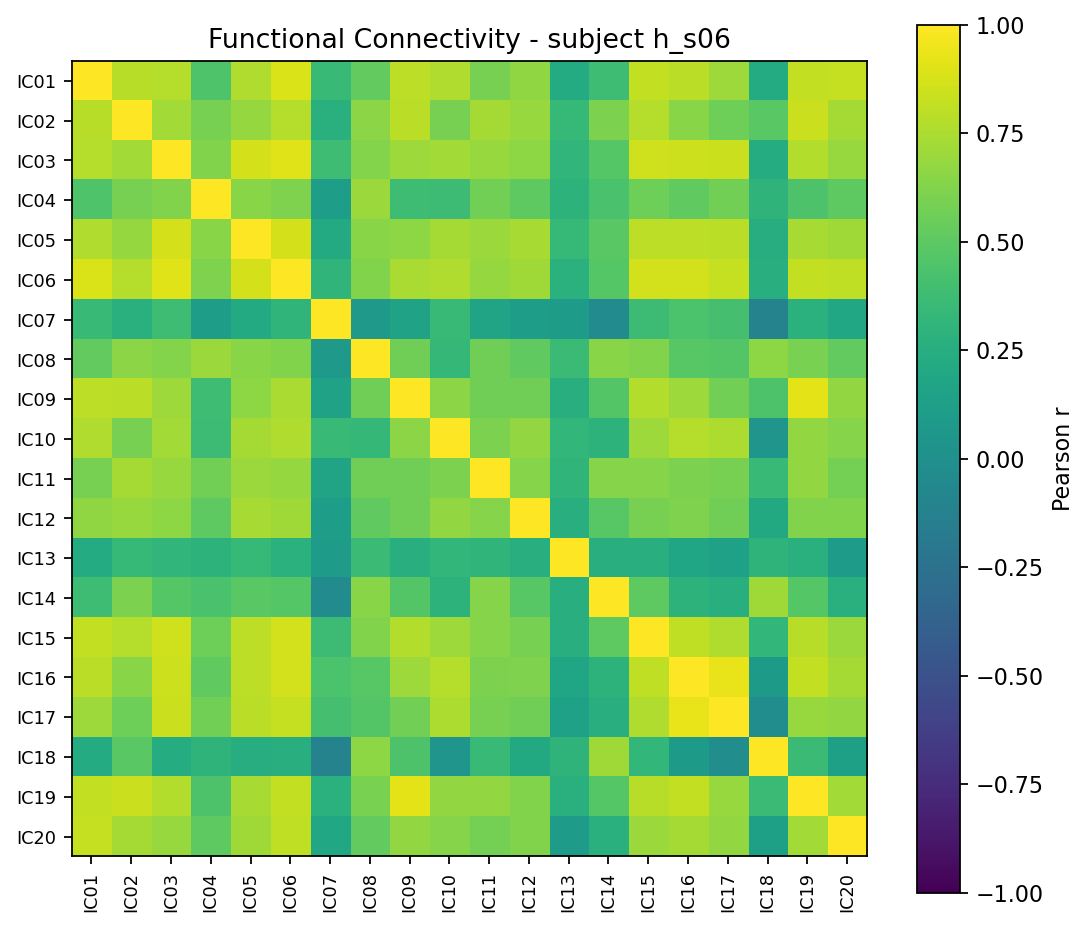

In [17]:
data = df1_plot  

corr = data.corr().values # defaut: Pearson
labels = list(data.columns)


plt.figure(figsize=(7, 6), dpi=160)
im = plt.imshow(corr, vmin=-1, vmax=1)   
plt.title("Functional Connectivity - subject h_s06")
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)
plt.colorbar(im, label="Pearson r")
plt.tight_layout()
plt.show()

### FC dynamic

In [ ]:

data = df1_plot           
labels = list(data.columns)

TR = 2.2
# WINDOW_TR = 30             
WINDOW_TR = 30  # 22 time points, ~50s,10个TR；(15-20 TR)
STEP_TR = 1           
USE_FISHER_Z = True     

X = data.values            # (T, 20)
T, K = X.shape
assert K == 20, f"Expected 20 components, got {K}"


starts = np.arange(0, T - WINDOW_TR + 1, STEP_TR)
n_windows = len(starts)

fc_windows = np.zeros((n_windows, K, K), dtype=float)

for w, s in enumerate(starts):
    seg = X[s:s+WINDOW_TR, :]                 # (WINDOW_TR, 20)
    C = np.corrcoef(seg, rowvar=False)        # (20, 20), Pearson r

    if USE_FISHER_Z:
        
        C = np.clip(C, -0.999999, 0.999999)
        C = np.arctanh(C)                     # Fisher z

    fc_windows[w] = C

# SD of dynamic FC 

fc_sd = fc_windows.std(axis=0, ddof=1)        # (20, 20)

print("T =", T, "K =", K)
print("Window TR =", WINDOW_TR, "Step TR =", STEP_TR)
print("n_windows =", n_windows)
print("fc_windows shape:", fc_windows.shape)
print("fc_sd shape:", fc_sd.shape)


T = 220 K = 20
Window TR = 30 Step TR = 1
n_windows = 191
fc_windows shape: (191, 20, 20)
fc_sd shape: (20, 20)


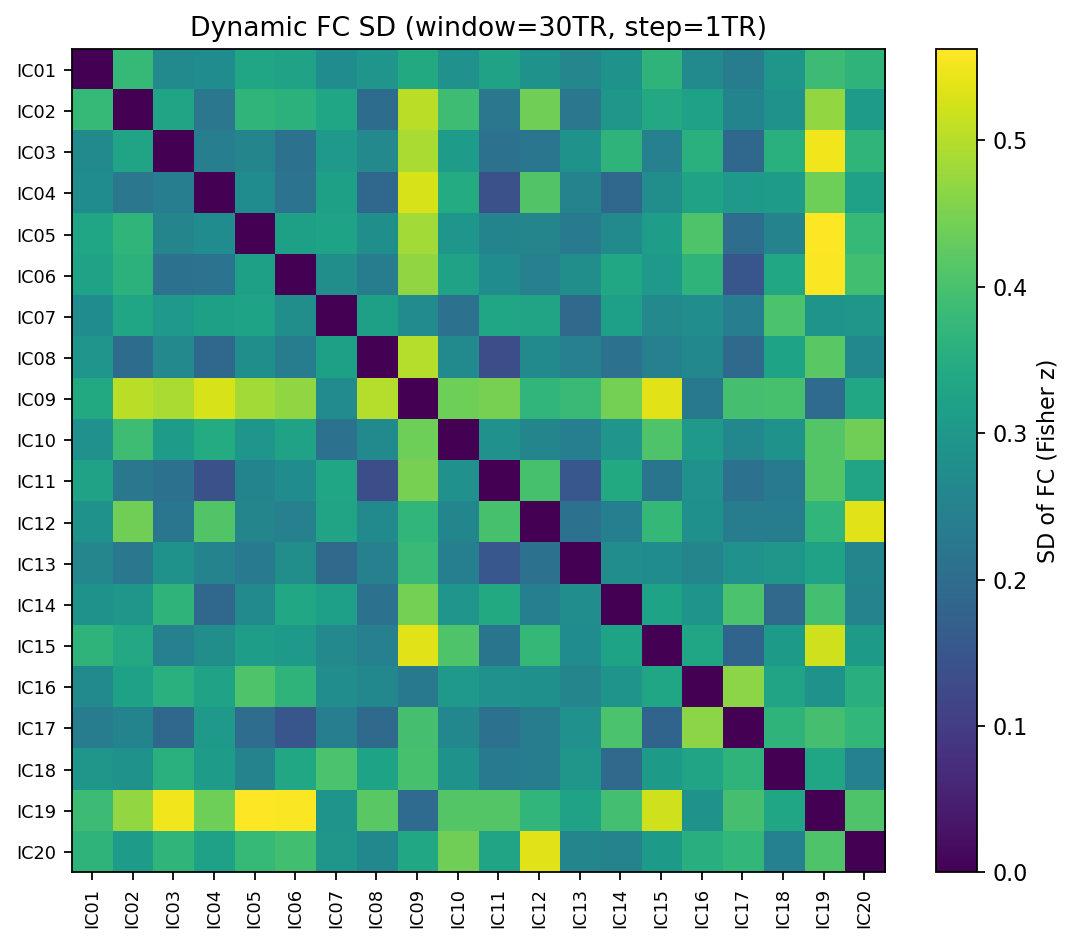

In [ ]:
plt.figure(figsize=(7, 6), dpi=160)
im = plt.imshow(fc_sd, aspect="auto")  
plt.title(f"Dynamic FC SD (window={WINDOW_TR}TR, step={STEP_TR}TR)")
plt.xticks(range(K), labels, rotation=90, fontsize=8)
plt.yticks(range(K), labels, fontsize=8)
plt.colorbar(im, label="SD of FC (Fisher z)" if USE_FISHER_Z else "SD of FC (r)")
plt.tight_layout()
plt.show()


多重比较校正：筛选哪些是多重比较得出的阳性
非线性的模型：3-4个；（SVM，random forest； Lasso；ridge）

In [20]:
mask_offdiag = ~np.eye(K, dtype=bool)
mean_sd_offdiag = fc_sd[mask_offdiag].mean()
print("Mean SD (off-diagonal edges):", mean_sd_offdiag)


Mean SD (off-diagonal edges): 0.3143020575812959


# ALFF

In [21]:
# ─── 参数设置 ───────────────────────────────────────────
DATA_DIR = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO"
OUT_DIR  = os.path.join(DATA_DIR, "output_alff")
os.makedirs(OUT_DIR, exist_ok=True)
TR         = 2.2
LOW_F      = 0.01
HIGH_F     = 0.1
DETREND    = False
STANDARDIZE = False
EPS        = 1e-12

## Mask

(197, 233, 189)


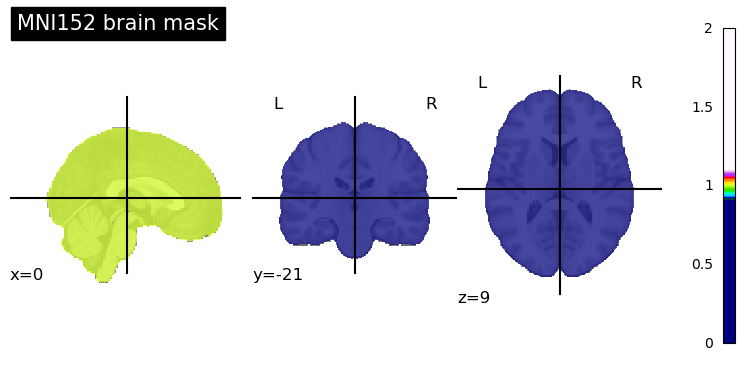

In [22]:
mni_mask = datasets.load_mni152_brain_mask()

print(mni_mask.shape)
plotting.plot_roi(mni_mask, title="MNI152 brain mask")
plotting.show()

## Definition of ALFF function

In [ ]:
# ─── 核心函数 ────────────────────────────────────────────
def compute_alff_falff(img_4d, mask_img, tr, low_f, high_f,
                        detrend=False, standardize=False, eps=1e-12):
    """
    Parameters
    ----------
    img_4d   : 4D NIfTI image
    mask_img : 3D brain mask
    tr       : repetition time (seconds)
    low_f    : lower bound of low-frequency band (Hz)
    high_f   : upper bound of low-frequency band (Hz)

    Returns
    -------
    alff_vals  : (V,) raw ALFF
    malff_vals : (V,) mean-normalised ALFF
    falff_vals : (V,) fractional ALFF
    masker     : fitted NiftiMasker (needed for inverse_transform)
    """


    masker = NiftiMasker(
        mask_img=mask_img,
        detrend=detrend,
        standardize=standardize,
        t_r=tr
    ) 
    Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）
    T = Y.shape[0]


    Y = Y - Y.mean(axis=0, keepdims=True) 


    fft_coeffs = np.fft.rfft(Y, axis=0)   
    amp        = np.abs(fft_coeffs)        
    freqs      = np.fft.rfftfreq(T, d=tr) 


    nyquist    = 0.5 / tr
    band_low   = (freqs >= low_f) & (freqs <= high_f)
    band_total = (freqs >  0)    & (freqs <= nyquist)

    if not np.any(band_low):
        raise ValueError(f"No frequency bins in low band [{low_f}, {high_f}] Hz. "
                        f"Check TR={tr} and T={T}.")


    alff_vals  = amp[band_low, :].mean(axis=0)           # (V,)


    malff_vals = alff_vals / (alff_vals.mean() + eps)    # (V,)

    
    # low_power   = (amp[band_low,   :] ** 2).sum(axis=0) # (V,)
    # total_power = (amp[band_total, :] ** 2).sum(axis=0) # (V,)
    # falff_vals  = low_power / (total_power + eps)        # (V,)
    low_amp   = amp[band_low, :].sum(axis=0)
    total_amp = amp[band_total, :].sum(axis=0)
    falff_vals = low_amp / (total_amp + eps)

    return alff_vals, malff_vals, falff_vals, masker


## batch calculation

In [ ]:

DATA_DIR = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO"
OUT_DIR = os.path.join(DATA_DIR, "output_alff")
os.makedirs(OUT_DIR, exist_ok=True)


subj_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_rs_4mm.nii.gz")))
print("Number of subject files found:", len(subj_files))

summary_rows = []
failed_cases = []


for i, subj_file in enumerate(subj_files, start=1):
    subj_name = os.path.basename(subj_file)

    if not subj_name.endswith("_rs_4mm.nii.gz"):
        raise ValueError(f"Unexpected filename format: {subj_name}")

    subj_id = subj_name.replace("_rs_4mm.nii.gz", "")

    print("\n" + "=" * 70)
    print(f"[{i}/{len(subj_files)}] Processing: {subj_id}")

    try:
        img = nib.load(subj_file)
        # print("FMRI shape:", img.shape)


        mask_img = resample_to_img(
            source_img=mni_mask,
            target_img=img.slicer[:, :, :, 0],
            interpolation="nearest",
            force_resample=True,
            copy_header=True
        )

        mask_data = mask_img.get_fdata()
        n_mask_voxels = int(np.sum(mask_data > 0))
        # print("Mask voxels:", n_mask_voxels)

        # 3)  ALFF / mALFF / fALFF
        alff_vals, malff_vals, falff_vals, masker = compute_alff_falff(
            img_4d      = img,
            mask_img    = mask_img,
            tr          = TR,
            low_f       = LOW_F,
            high_f      = HIGH_F,
            detrend     = True,
            standardize = False
        )

        # print("ALFF shape:", alff_vals.shape)
        # print("ALFF mean :", float(alff_vals.mean()))
        # print("ALFF range:", float(alff_vals.min()), "~", float(alff_vals.max()))
        # print("fALFF mean:", float(falff_vals.mean()))
        # print("fALFF range:", float(falff_vals.min()), "~", float(falff_vals.max()))

        # 4) 转回 3D 图像
        alff_img  = masker.inverse_transform(alff_vals)
        malff_img = masker.inverse_transform(malff_vals)
        falff_img = masker.inverse_transform(falff_vals)

        # 5) 保存结果
        mask_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_mask_mni152.nii.gz"))
        alff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_alff.nii.gz"))
        malff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_malff.nii.gz"))
        falff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_falff.nii.gz"))

        # 6) 记录 summary
        summary_rows.append({
            "subj_id": subj_id,
            "fmri_shape": str(img.shape),
            "mask_voxels": n_mask_voxels,
            "alff_mean": float(alff_vals.mean()),
            "alff_min": float(alff_vals.min()),
            "alff_max": float(alff_vals.max()),
            "malff_mean": float(malff_vals.mean()),
            "malff_min": float(malff_vals.min()),
            "malff_max": float(malff_vals.max()),
            "falff_mean": float(falff_vals.mean()),
            "falff_min": float(falff_vals.min()),
            "falff_max": float(falff_vals.max())
        })

        print("Done:", subj_id)

    except Exception as e:
        print("FAILED:", subj_id)
        print("Error :", str(e))
        failed_cases.append({
            "subj_id": subj_id,
            "error": str(e)
        })

# =========================
#  summary 
# =========================
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUT_DIR, "alff_summary.csv"), index=False)

if failed_cases:
    failed_df = pd.DataFrame(failed_cases)
    failed_df.to_csv(os.path.join(OUT_DIR, "alff_failed_cases.csv"), index=False)

print("\n" + "=" * 70)
print("Batch finished.")
print("Successful subjects:", len(summary_rows))
print("Failed subjects:", len(failed_cases))
print("Results saved in:", OUT_DIR)

Number of subject files found: 49

[1/49] Processing: h_s06


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s06

[2/49] Processing: h_s07


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s07

[3/49] Processing: h_s08


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s08

[4/49] Processing: h_s124


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s124

[5/49] Processing: h_s126


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s126

[6/49] Processing: h_s13


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s13

[7/49] Processing: h_s15


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s15

[8/49] Processing: h_s21


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s21

[9/49] Processing: h_s26


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s26

[10/49] Processing: h_s28


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s28

[11/49] Processing: h_s31


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s31

[12/49] Processing: h_s35


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s35

[13/49] Processing: h_s37


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s37

[14/49] Processing: h_s40


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s40

[15/49] Processing: h_s44


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s44

[16/49] Processing: h_s48


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s48

[17/49] Processing: h_s49


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s49

[18/49] Processing: h_s51


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: h_s51

[19/49] Processing: p_s04


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s04

[20/49] Processing: p_s10


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s10

[21/49] Processing: p_s11


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s11

[22/49] Processing: p_s17


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s17

[23/49] Processing: p_s18


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s18

[24/49] Processing: p_s22


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s22

[25/49] Processing: p_s29


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s29

[26/49] Processing: p_s30


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s30

[27/49] Processing: p_s33


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s33

[28/49] Processing: p_s34


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s34

[29/49] Processing: p_s39


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s39

[30/49] Processing: p_s42


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s42

[31/49] Processing: p_s45


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s45

[32/49] Processing: p_s47


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s47

[33/49] Processing: p_s52


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: p_s52

[34/49] Processing: s_s09


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s09

[35/49] Processing: s_s12


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s12

[36/49] Processing: s_s14


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s14

[37/49] Processing: s_s16


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s16

[38/49] Processing: s_s19


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s19

[39/49] Processing: s_s23


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s23

[40/49] Processing: s_s25


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s25

[41/49] Processing: s_s27


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s27

[42/49] Processing: s_s32


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s32

[43/49] Processing: s_s36


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s36

[44/49] Processing: s_s38


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s38

[45/49] Processing: s_s41


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s41

[46/49] Processing: s_s43


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s43

[47/49] Processing: s_s46


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s46

[48/49] Processing: s_s50


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s50

[49/49] Processing: s_s53


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


Done: s_s53

Batch finished.
Successful subjects: 49
Failed subjects: 0
Results saved in: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/output_alff


## Single subject check

In [25]:
print(img.shape[:3], mni_mask.shape)
print(np.allclose(img.affine, mni_mask.affine))

(45, 54, 45) (197, 233, 189)
False


In [ ]:

subj_file = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s40_rs_4mm.nii.gz"
subj_id   = "h_s40"


img = nib.load(subj_file)
print("FMRI Shape:", img.shape)  #  (45, 54, 45, T)
# mask_img_subj = compute_epi_mask(img) # mask based on single subject


OUT_DIR = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/output"



mask_img = resample_to_img(
    source_img=mni_mask,
    target_img=img.slicer[:, :, :, 0],   
    interpolation="nearest",             
    force_resample=True,
    copy_header=True
)

# 计算ALFF
alff_vals, malff_vals, falff_vals, masker = compute_alff_falff(
    img_4d      = img,
    # mask_img    = mask_img_subj,
    mask_img=mask_img,
    tr          = TR,
    low_f       = LOW_F,
    high_f      = HIGH_F,
    detrend     = DETREND,
    standardize = STANDARDIZE
)

print("ALFF shape:", alff_vals.shape)   
print("ALFF mean:", alff_vals.mean())
print("ALFF range:", alff_vals.min(), "~", alff_vals.max())


alff_img  = masker.inverse_transform(alff_vals)
malff_img = masker.inverse_transform(malff_vals)
falff_img = masker.inverse_transform(falff_vals)



mask_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_mask_mni152.nii.gz"))
alff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_alff.nii.gz"))
malff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_malff.nii.gz"))
falff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id}_falff.nii.gz"))

print("Done:", subj_id)
print("Saved to:", OUT_DIR)

FMRI Shape: (45, 54, 45, 220)


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


ALFF shape: (29398,)
ALFF mean: 644.6459
ALFF range: 0.0 ~ 6342.845
Done: h_s40
Saved to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/output


### Visualization

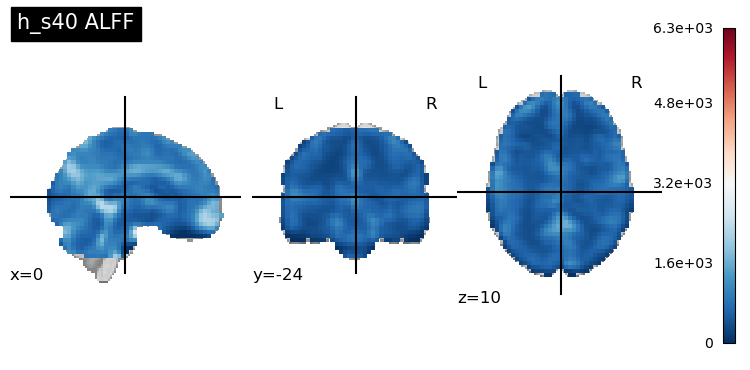

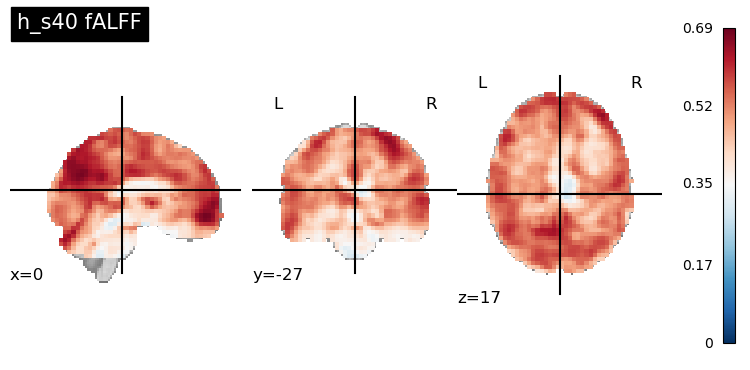

In [27]:
plotting.plot_stat_map(alff_img, title=f"{subj_id} ALFF", colorbar=True)
plotting.plot_stat_map(falff_img, title=f"{subj_id} fALFF", colorbar=True)
plotting.show()

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



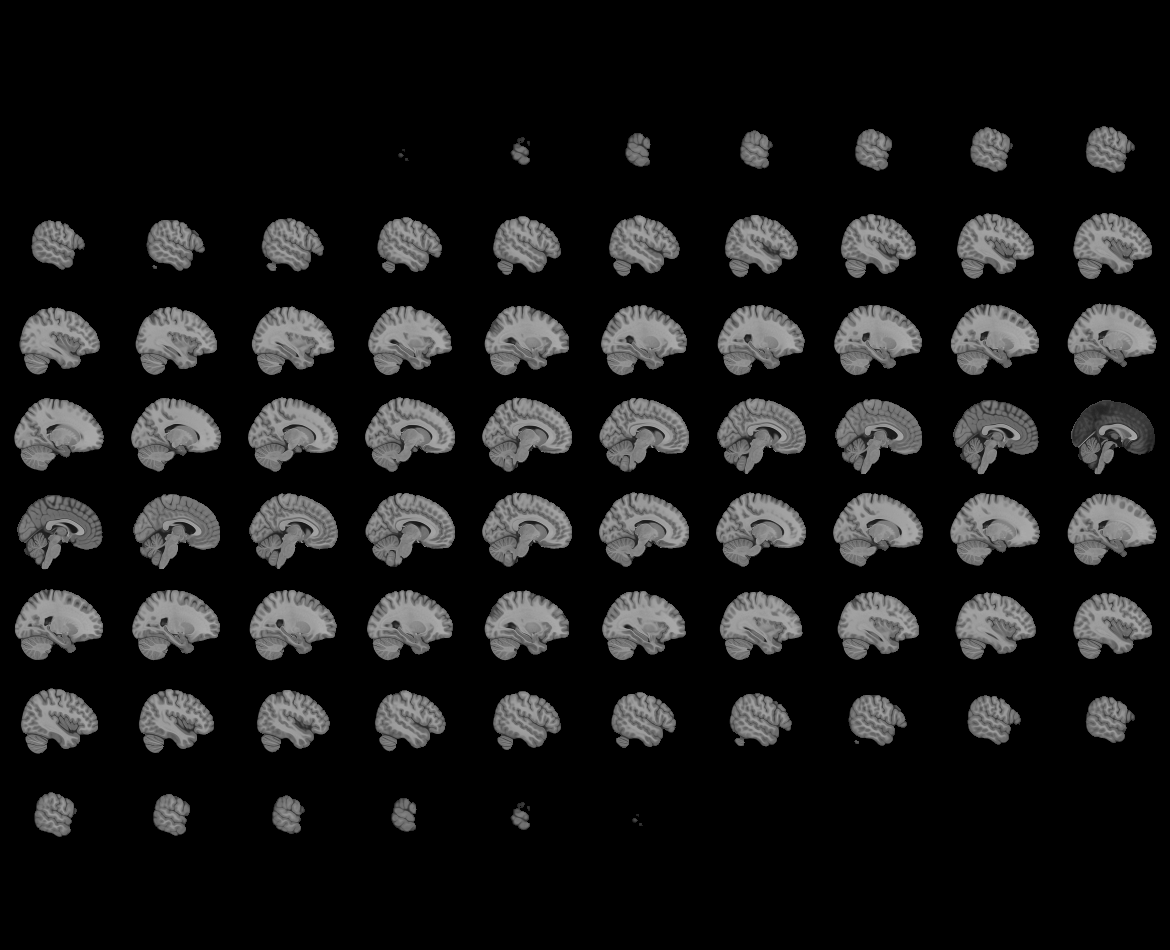
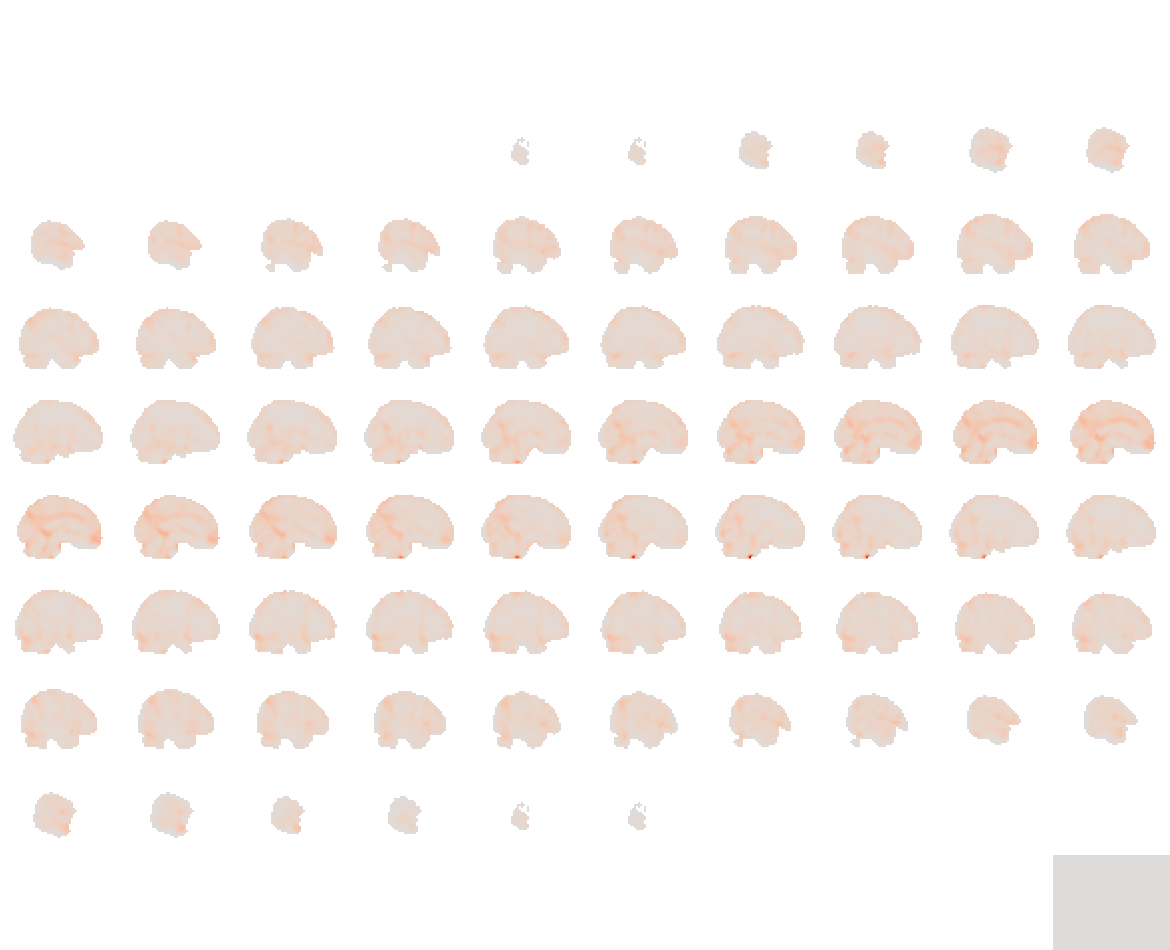

In [ ]:

viewer_alff = plotting.view_img(alff_img, title=f"{subj_id} ALFF", cmap="coolwarm")
viewer_alff

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



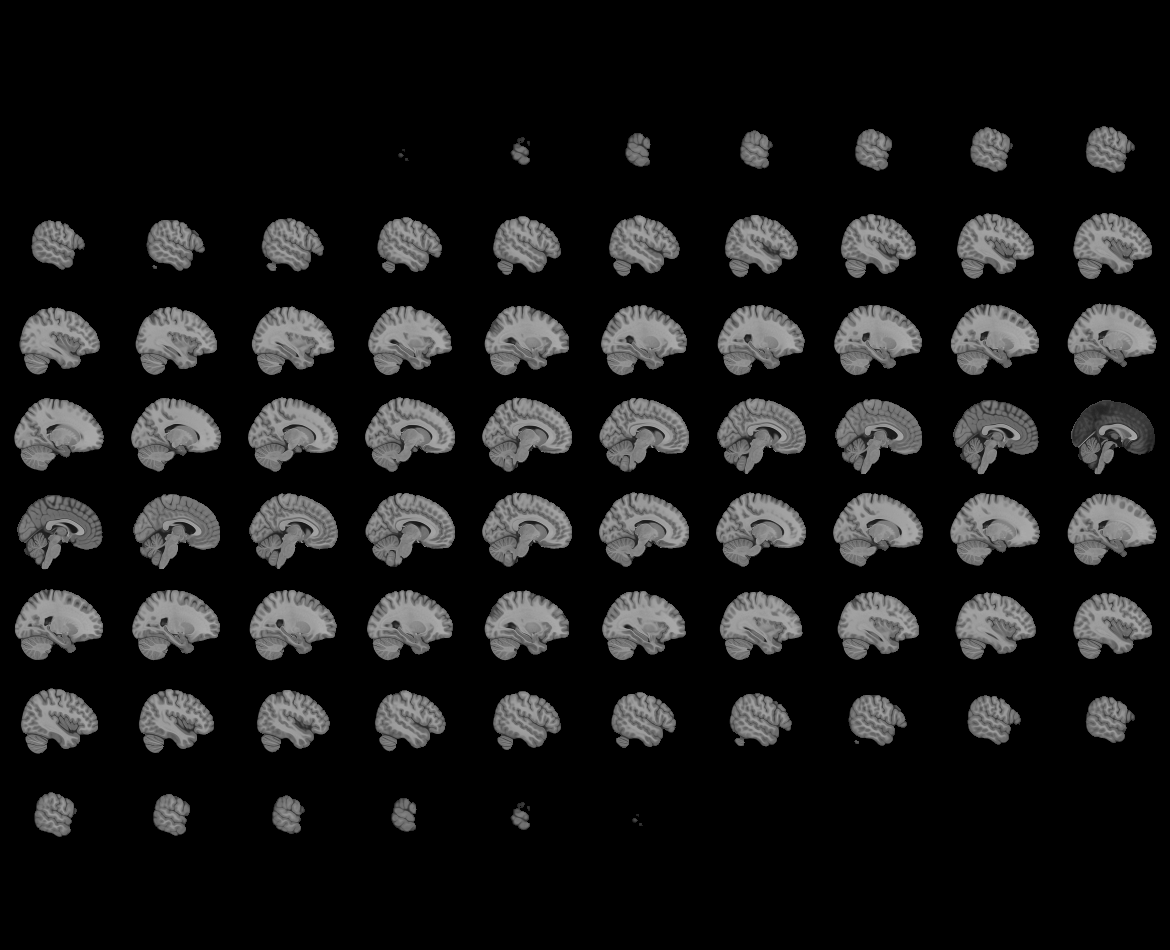
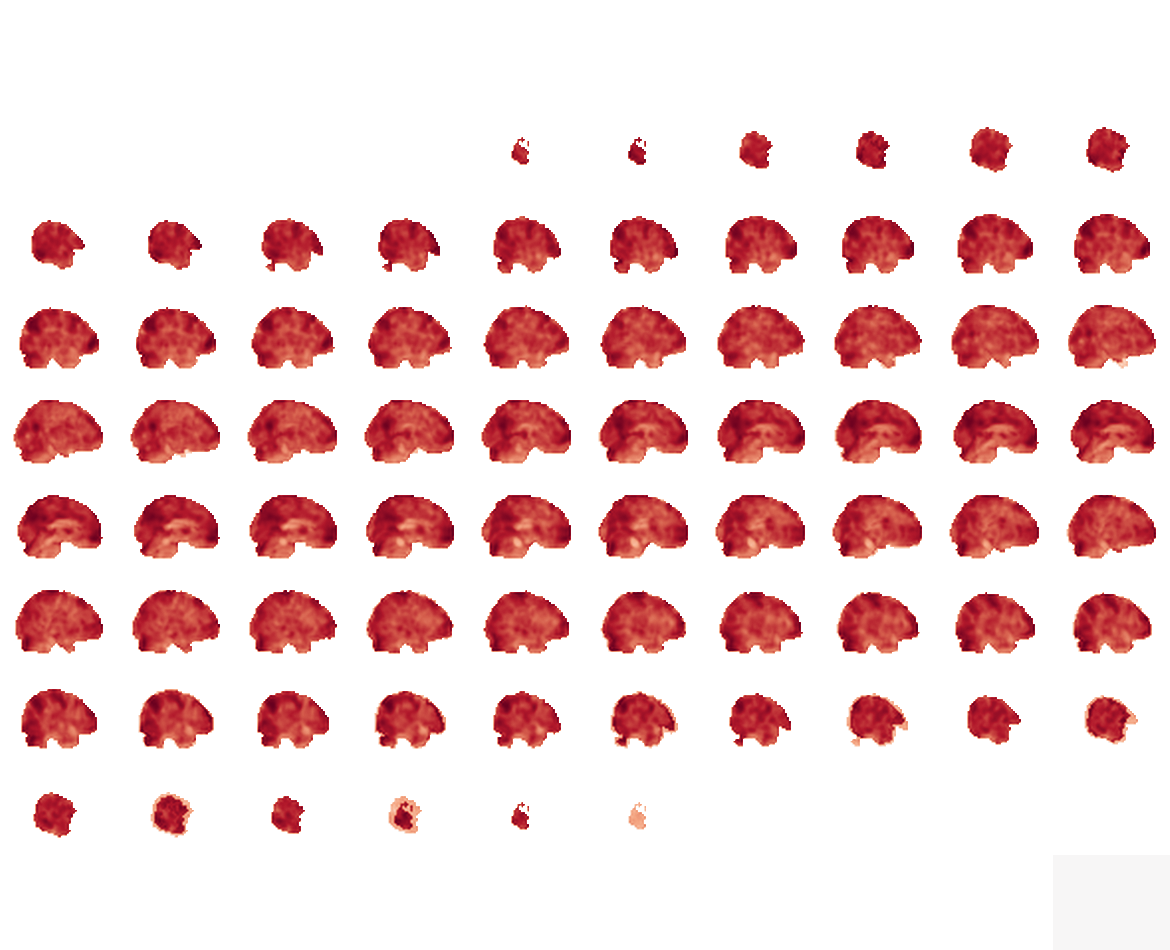

In [ ]:

viewer_falff = plotting.view_img(falff_img, title=f"{subj_id} ALFF", cmap="RdBu_r")
viewer_falff

### other individual

no value or low values???

In [ ]:

subj_file2 = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/h_s06_rs_4mm.nii.gz"
subj_id2   = "h_s06"



img = nib.load(subj_file2)
print("FMRI Shape:", img.shape)  #  (45, 54, 45, T)
# mask_img_subj = compute_epi_mask(img) # mask based on single subject


OUT_DIR = "/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/output"


mask_img = resample_to_img(
    source_img=mni_mask,
    target_img=img.slicer[:, :, :, 0],   
    interpolation="nearest",            
    force_resample=True,
    copy_header=True
)


alff_vals, malff_vals, falff_vals, masker = compute_alff_falff(
    img_4d      = img,
    # mask_img    = mask_img_subj,
    mask_img=mask_img,
    tr          = TR,
    low_f       = LOW_F,
    high_f      = HIGH_F,
    detrend     = DETREND,
    standardize = STANDARDIZE
)

print("ALFF shape:", alff_vals.shape)  
print("ALFF mean:", alff_vals.mean())
print("ALFF range:", alff_vals.min(), "~", alff_vals.max())


alff_img  = masker.inverse_transform(alff_vals)
malff_img = masker.inverse_transform(malff_vals)
falff_img = masker.inverse_transform(falff_vals)



mask_img.to_filename(os.path.join(OUT_DIR, f"{subj_id2}_mask_mni152.nii.gz"))
alff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id2}_alff.nii.gz"))
malff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id2}_malff.nii.gz"))
falff_img.to_filename(os.path.join(OUT_DIR, f"{subj_id2}_falff.nii.gz"))

print("Done:", subj_id2)
print("Saved to:", OUT_DIR)

FMRI Shape: (45, 54, 45, 220)


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_23000/4007139809.py:29: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  Y = masker.fit_transform(img_4d)   # (T, V)（220,24915）


ALFF shape: (29398,)
ALFF mean: 1286.0139
ALFF range: 0.0 ~ 16464.541
Done: h_s06
Saved to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/HALO/output


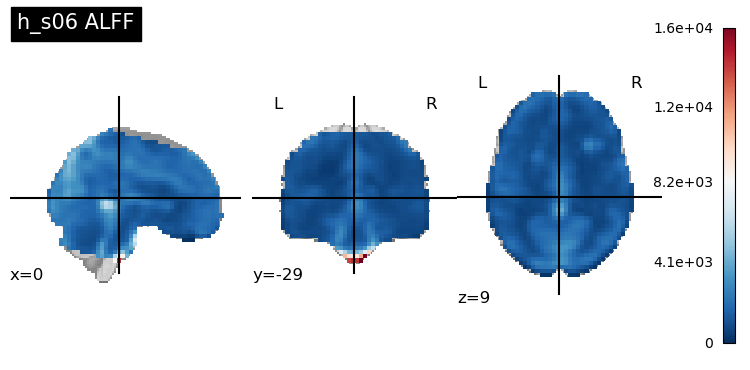

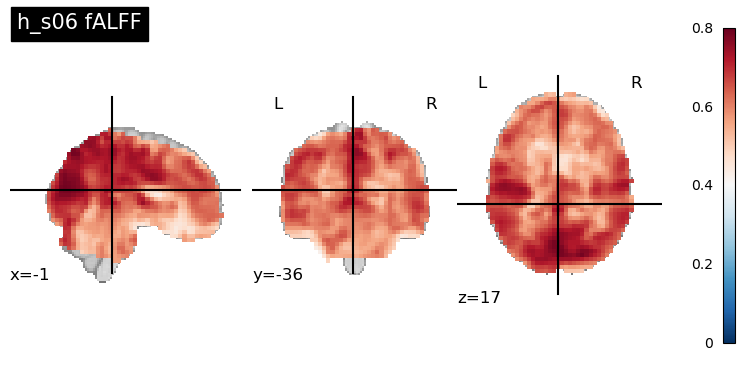

In [31]:
plotting.plot_stat_map(alff_img, title=f"{subj_id2} ALFF", colorbar=True)
plotting.plot_stat_map(falff_img, title=f"{subj_id2} fALFF", colorbar=True)
plotting.show()

# Compute features for all subjects

## Functions definition

### matrice Fisher z(optional)

In [ ]:
def fisher_z_mat(C, eps=1e-6):
    C = np.clip(C, -1 + eps, 1 - eps)
    return np.arctanh(C)



### get upper triangle - 190 parameters

In [ ]:
def upper_tri_vec(M, k=1): #K=1 means not include the diagnol
    iu = np.triu_indices(M.shape[0], k=k)
    return M[iu]



### static FC：from time courses of 20 components

In [ ]:
def static_fc_vec(tc, fisher=False): 
    C = np.corrcoef(tc, rowvar=False)  
    
    if fisher:
        C = fisher_z_mat(C)
    return C, upper_tri_vec(C, k=1) 

### dynamic FC (SD)：sliding windows 

In [ ]:
def dfc_sd_vec(tc, window_tr, step_tr, fisher=False, ddof_sd=1):
    T, K = tc.shape
    starts = np.arange(0, T - window_tr + 1, step_tr) 
    nW = len(starts) 

    edges = []
    for s in starts:
        seg = tc[s:s+window_tr, :]
        C = np.corrcoef(seg, rowvar=False) 
        if fisher:
            C = fisher_z_mat(C)
        edges.append(upper_tri_vec(C, k=1)) # (190,)

    edges = np.vstack(edges)                 # (nW, 190)
    sd_vec = edges.std(axis=0, ddof=ddof_sd) # (190,)
    return sd_vec, nW

### compute the parameters for all subjects

In [36]:
N_COMPONENTS = 20
# WINDOW_TR = 30 
WINDOW_TR = 50
# STEP_TR = 1
STEP_TR = 5
USE_FISHER_Z = False
DDOF_SD = 1

In [ ]:
# ---- batch over subjects ----
tsv_files = sorted(glob.glob(os.path.join(OUT_STEP1, "*_step1_timecourses.tsv"))) 
subject_ids, X_static, X_dfc_sd, meta = [], [], [], []

for fp in tsv_files:
    subj_id = os.path.basename(fp).replace("_step1_timecourses.tsv", "").replace("_rs_4mm", "")
    df = pd.read_csv(fp, sep="\t")
    tc = df.values  

    C_static, v_static = static_fc_vec(tc, fisher=USE_FISHER_Z)
    v_dfc_sd, nW = dfc_sd_vec(tc, WINDOW_TR, STEP_TR, fisher=USE_FISHER_Z, ddof_sd=DDOF_SD)

    subject_ids.append(subj_id) 
    X_static.append(v_static) 
    X_dfc_sd.append(v_dfc_sd) 
    meta.append({"subject_id": subj_id, "T": tc.shape[0], "n_windows": nW})

X_static = np.vstack(X_static)      # (n_subj, 190)
X_dfc_sd = np.vstack(X_dfc_sd)      # (n_subj, 190)
X_concat = np.hstack([X_static, X_dfc_sd])  # (n_subj, 380)
meta_df = pd.DataFrame(meta)

print("X_static:", X_static.shape)
print("X_dfc_sd:", X_dfc_sd.shape)
print("X_concat:", X_concat.shape)


X_static: (49, 190)
X_dfc_sd: (49, 190)
X_concat: (49, 380)


In [38]:
for i in range(5):
    print(i, os.path.basename(tsv_files[i]), "->", subject_ids[i])

0 h_s06_rs_4mm_step1_timecourses.tsv -> h_s06
1 h_s07_rs_4mm_step1_timecourses.tsv -> h_s07
2 h_s08_rs_4mm_step1_timecourses.tsv -> h_s08
3 h_s124_rs_4mm_step1_timecourses.tsv -> h_s124
4 h_s126_rs_4mm_step1_timecourses.tsv -> h_s126


In [ ]:

edges = [(i, j) for i in range(N_COMPONENTS) for j in range(i+1, N_COMPONENTS)]
static_cols = [f"FC_IC{i+1:02d}_IC{j+1:02d}" for i, j in edges]

X_static_df = pd.DataFrame(X_static, index=subject_ids, columns=static_cols)

# print(X_static_df.shape)
# display(X_static_df)        

In [ ]:
print("min / max:", X_static.min(), X_static.max())
print("mean / std:", X_static.mean(), X_static.std())

row_means = X_static.mean(axis=1)
print("row means:", row_means[:10])
print("row mean min/max:", row_means.min(), row_means.max())

min / max: -0.6443869443962189 0.9441837176920751
mean / std: 0.3577780070315656 0.2642468543741549
row means: [0.54366793 0.37392021 0.22811883 0.45511643 0.33508707 0.28777213
 0.37645676 0.26764226 0.50764505 0.51343439]
row mean min/max: 0.19266184612290746 0.5436679318772004


In [41]:
print("Any abs>1?", np.any(np.abs(X_static) > 1))

Any abs>1? False


## concacate fc and fc dynamic with falff 

In [42]:
for f in sorted(glob.glob(os.path.join(DATA_DIR, "*_rs_4mm.nii.gz"))):
    img = nib.load(f)
    print(os.path.basename(f), img.shape, img.affine)

h_s06_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s07_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s08_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s124_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s126_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s13_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
h_s15_rs_4mm.nii.gz (45, 54, 45, 220) [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72

In [43]:
print("mni_mask shape:", mni_mask.shape)
print("mni_mask affine:\n", mni_mask.affine)

mni_mask shape: (197, 233, 189)
mni_mask affine:
 [[   1.    0.    0.  -98.]
 [   0.    1.    0. -134.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]


In [ ]:


ALFF_DIR = os.path.join(DATA_DIR, "output_alff")


fc_subject_ids = subject_ids.copy()


ref_func_file = sorted(glob.glob(os.path.join(DATA_DIR, "*_rs_4mm.nii.gz")))[0]
ref_img = nib.load(ref_func_file)

common_mask_img = resample_to_img(
    source_img=mni_mask,
    target_img=ref_img.slicer[:, :, :, 0],
    interpolation="nearest",
    force_resample=True,
    copy_header=True
)

common_mask = common_mask_img.get_fdata() > 0
print("common_mask shape:", common_mask.shape)
print("n common mask voxels:", int(common_mask.sum()))


falff_files = sorted(glob.glob(os.path.join(ALFF_DIR, "*_falff.nii.gz")))
print("Number of fALFF files found:", len(falff_files))

falff_dict = {}

for fp in falff_files:
    fname = os.path.basename(fp)


    subj_id = fname.replace("_falff.nii.gz", "")

    img_falff = nib.load(fp)
    data_falff = img_falff.get_fdata()

    if data_falff.shape != common_mask.shape:
        raise ValueError(
            f"Shape mismatch for {subj_id}: {data_falff.shape} vs {common_mask.shape}"
        )

    vec_falff = data_falff[common_mask]
    falff_dict[subj_id] = vec_falff


X_falff = []
missing_ids = []

for subj_id in fc_subject_ids:
    if subj_id not in falff_dict:
        missing_ids.append(subj_id)
    else:
        X_falff.append(falff_dict[subj_id])

if len(missing_ids) > 0:
    raise ValueError(f"Missing fALFF files for subjects: {missing_ids}")

X_falff = np.vstack(X_falff)

print("X_static shape :", X_static.shape)
print("X_dfc_sd shape :", X_dfc_sd.shape)
print("X_falff shape  :", X_falff.shape)


X_concat_all = np.hstack([X_static, X_dfc_sd, X_falff])
print("X_concat_all shape:", X_concat_all.shape)

common_mask shape: (45, 54, 45)
n common mask voxels: 29398
Number of fALFF files found: 49
X_static shape : (49, 190)
X_dfc_sd shape : (49, 190)
X_falff shape  : (49, 29398)
X_concat_all shape: (49, 29778)


## define label

In [ ]:
raw_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_rs_4mm.nii.gz")))

raw_subject_ids = []
raw_labels = []

group_map = {
    "h": "haloperidol",
    "p": "placebo",
    "s": "levodopa"
}

for fp in raw_files:
    fname = os.path.basename(fp)   
    
    
    subj_id = fname.replace("_rs_4mm.nii.gz", "")
    raw_subject_ids.append(subj_id)
    

    prefix = subj_id.split("_")[0]
    
    if prefix not in group_map:
        raise ValueError(f"Unknown group prefix in filename: {fname}")
    
    raw_labels.append(group_map[prefix])

raw_subject_ids = np.array(raw_subject_ids)
raw_labels = np.array(raw_labels)

print("n raw subjects:", len(raw_subject_ids))
print("label counts:", np.unique(raw_labels, return_counts=True))
print(raw_subject_ids[:10])
print(raw_labels[:10])

n raw subjects: 49
label counts: (array(['haloperidol', 'levodopa', 'placebo'], dtype='<U11'), array([18, 16, 15]))
['h_s06' 'h_s07' 'h_s08' 'h_s124' 'h_s126' 'h_s13' 'h_s15' 'h_s21' 'h_s26'
 'h_s28']
['haloperidol' 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol'
 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol']


In [46]:
fc_subject_ids = np.array(fc_subject_ids)

print("n fc subjects:", len(fc_subject_ids))
print("n raw subjects:", len(raw_subject_ids))

n fc subjects: 49
n raw subjects: 49


In [47]:
fc_subject_ids = np.array(fc_subject_ids)

print("n fc subjects:", len(fc_subject_ids))
print("n raw subjects:", len(raw_subject_ids))

n fc subjects: 49
n raw subjects: 49


In [48]:
same_order = np.array_equal(fc_subject_ids, raw_subject_ids)
print("顺序和内容是否完全一致:", same_order)

if not np.array_equal(fc_subject_ids, raw_subject_ids):
    print("发现不一致的位置：")
    for i, (a, b) in enumerate(zip(fc_subject_ids, raw_subject_ids)):
        if a != b:
            print(f"Index {i}: fc_subject_ids={a}, raw_subject_ids={b}")

顺序和内容是否完全一致: True


In [49]:
np.array_equal(fc_subject_ids, raw_subject_ids) == True

y = raw_labels.copy()
print("y shape:", y.shape)
print("X_concat_all shape:", X_concat_all.shape)
print(y)

y shape: (49,)
X_concat_all shape: (49, 29778)
['haloperidol' 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol'
 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol'
 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol' 'haloperidol'
 'haloperidol' 'haloperidol' 'haloperidol' 'placebo' 'placebo' 'placebo'
 'placebo' 'placebo' 'placebo' 'placebo' 'placebo' 'placebo' 'placebo'
 'placebo' 'placebo' 'placebo' 'placebo' 'placebo' 'levodopa' 'levodopa'
 'levodopa' 'levodopa' 'levodopa' 'levodopa' 'levodopa' 'levodopa'
 'levodopa' 'levodopa' 'levodopa' 'levodopa' 'levodopa' 'levodopa'
 'levodopa' 'levodopa']


In [50]:
assert X_concat_all.shape[0] == len(y)

In [51]:
# check
print("fc_subject_ids:")
print(fc_subject_ids)

print("\nraw_subject_ids:")
print(raw_subject_ids)

fc_subject_ids:
['h_s06' 'h_s07' 'h_s08' 'h_s124' 'h_s126' 'h_s13' 'h_s15' 'h_s21' 'h_s26'
 'h_s28' 'h_s31' 'h_s35' 'h_s37' 'h_s40' 'h_s44' 'h_s48' 'h_s49' 'h_s51'
 'p_s04' 'p_s10' 'p_s11' 'p_s17' 'p_s18' 'p_s22' 'p_s29' 'p_s30' 'p_s33'
 'p_s34' 'p_s39' 'p_s42' 'p_s45' 'p_s47' 'p_s52' 's_s09' 's_s12' 's_s14'
 's_s16' 's_s19' 's_s23' 's_s25' 's_s27' 's_s32' 's_s36' 's_s38' 's_s41'
 's_s43' 's_s46' 's_s50' 's_s53']

raw_subject_ids:
['h_s06' 'h_s07' 'h_s08' 'h_s124' 'h_s126' 'h_s13' 'h_s15' 'h_s21' 'h_s26'
 'h_s28' 'h_s31' 'h_s35' 'h_s37' 'h_s40' 'h_s44' 'h_s48' 'h_s49' 'h_s51'
 'p_s04' 'p_s10' 'p_s11' 'p_s17' 'p_s18' 'p_s22' 'p_s29' 'p_s30' 'p_s33'
 'p_s34' 'p_s39' 'p_s42' 'p_s45' 'p_s47' 'p_s52' 's_s09' 's_s12' 's_s14'
 's_s16' 's_s19' 's_s23' 's_s25' 's_s27' 's_s32' 's_s36' 's_s38' 's_s41'
 's_s43' 's_s46' 's_s50' 's_s53']


# Classification

## ElasticNet

### Placebo vs Haloperidol 

In [52]:

param_grid = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

cross_validation=StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

#### fc only

In [ ]:
# -------------------------------------------------
# Placebo vs Haloperidol | X_static
# -------------------------------------------------
mask_ph = np.isin(y, ["placebo", "haloperidol"])

X_ph_static = X_static[mask_ph]
y_ph_static = y[mask_ph]

print("X_ph shape:", X_ph_static.shape)
print("y_ph counts:", np.unique(y_ph_static, return_counts=True))

assert set(np.unique(y_ph_static)) == {"placebo", "haloperidol"}, "Unexpected labels!"
y_ph_static_bin = (y_ph_static == "haloperidol").astype(int)

print("y_ph_bin counts:", np.unique(y_ph_static_bin, return_counts=True))


pipe_en_ph = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


grid_ph_static = GridSearchCV(
    estimator=pipe_en_ph,
    param_grid=param_grid,
    cv=cross_validation,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_ph_static.fit(X_ph_static, y_ph_static_bin)

print("Best params:", grid_ph_static.best_params_)
print("Best CV AUC:", grid_ph_static.best_score_)  

results_df1 = pd.DataFrame(grid_ph_static.cv_results_)

print(
    results_df1[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",           
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"           
    ]].sort_values("rank_test_roc_auc")  
)

X_ph shape: (33, 190)
y_ph counts: (array(['haloperidol', 'placebo'], dtype='<U11'), array([18, 15]))
y_ph_bin counts: (array([0, 1]), array([15, 18]))
Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.5}
Best CV AUC: 0.6666666666666667
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
17         0.100                  0.5           0.666667          0.217307   
11         0.050                  0.3           0.633333          0.227303   
29         1.000                  0.9           0.627778          0.126198   
27         1.000                  0.5           0.627778          0.144444   
26         1.000                  0.3           0.627778          0.144444   
28         1.000                  0.7           0.627778          0.126198   
21         0.500                  0.3           0.611111          0.161971   
16         0.100                  0.3           0.611111          0.240242   
24         0.500                  0.9           0.594444       

##### permutation test


In [ ]:

best_C_static = grid_ph_static.best_params_["clf__C"]
best_l1_ratio_static = grid_ph_static.best_params_["clf__l1_ratio"]


best_model_static = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=best_C_static,
        l1_ratio=best_l1_ratio_static
    ))
])

# permutation test
score, perm_scores, pvalue_ph_static = permutation_test_score(
    estimator=best_model_static,
    X=X_ph_static,
    y=y_ph_static_bin,
    cv=cross_validation,
    scoring="roc_auc",          
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_ph_static.best_score_)
print("Observed AUC:           ", score)                        
print("Permutation p-value:    ", pvalue_ph_static)

GridSearchCV best AUC:   0.6666666666666667
Observed AUC:            0.6666666666666667
Permutation p-value:     0.15484515484515485


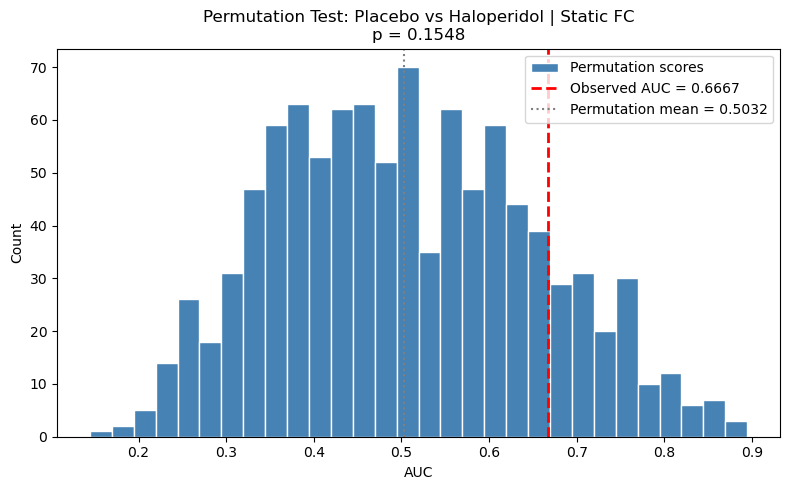

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(perm_scores, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score:.4f}")
plt.axvline(np.mean(perm_scores), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores):.4f}")
plt.xlabel("AUC")                                                               
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Haloperidol | Static FC\np = {pvalue_ph_static:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### fc dynamics

In [ ]:
# -------------------------------------------------
# Placebo vs Haloperidol | X_dfc_sd
# -------------------------------------------------
mask_ph = np.isin(y, ["placebo", "haloperidol"])
X_ph_dfc = X_dfc_sd[mask_ph]
y_ph_dfc = y[mask_ph]

print("X_ph_dfc shape:", X_ph_dfc.shape)
print("y_ph_dfc counts:", np.unique(y_ph_dfc, return_counts=True))

assert set(np.unique(y_ph_dfc)) == {"placebo", "haloperidol"}, "Unexpected labels!"
y_ph_dfc_bin = (y_ph_dfc == "haloperidol").astype(int)

print("y_ph_dfc_bin counts:", np.unique(y_ph_dfc_bin, return_counts=True))

pipe_en_ph_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])

grid_ph_dfc = GridSearchCV(
    estimator=pipe_en_ph_dfc,
    param_grid=param_grid,
    cv=cross_validation,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_ph_dfc.fit(X_ph_dfc, y_ph_dfc_bin)

print("Best params:", grid_ph_dfc.best_params_)
print("Best CV AUC:", grid_ph_dfc.best_score_)  

best_idx = grid_ph_dfc.best_index_
print("Placebo vs Haloperidol (Elastic Net, X_dfc_sd) | AUC:",          
      grid_ph_dfc.cv_results_["mean_test_roc_auc"][best_idx],            
      "+/-",
      grid_ph_dfc.cv_results_["std_test_roc_auc"][best_idx])             
print("Placebo vs Haloperidol (Elastic Net, X_dfc_sd) | Macro F1:",
      grid_ph_dfc.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_ph_dfc.cv_results_["std_test_f1_macro"][best_idx])

results_df_dfc = pd.DataFrame(grid_ph_dfc.cv_results_)
print(
    results_df_dfc[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_ph_dfc shape: (33, 190)
y_ph_dfc counts: (array(['haloperidol', 'placebo'], dtype='<U11'), array([18, 15]))
y_ph_dfc_bin counts: (array([0, 1]), array([15, 18]))
Best params: {'clf__C': 1.0, 'clf__l1_ratio': 0.1}
Best CV AUC: 0.5333333333333334
Placebo vs Haloperidol (Elastic Net, X_dfc_sd) | AUC: 0.5333333333333334 +/- 0.18542576964754043
Placebo vs Haloperidol (Elastic Net, X_dfc_sd) | Macro F1: 0.4904761904761905 +/- 0.13188842945129514
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
25         1.000                  0.1           0.533333          0.185426   
20         0.500                  0.1           0.516667          0.168142   
0          0.001                  0.1           0.500000          0.000000   
19         0.100                  0.9           0.500000          0.000000   
13         0.050                  0.7           0.500000          0.000000   
12         0.050                  0.5           0.500000          0.000000   
9       

##### permutation test

GridSearchCV best AUC:   0.5333333333333334
Observed AUC:            0.5333333333333334
Permutation p-value:     0.4305694305694306


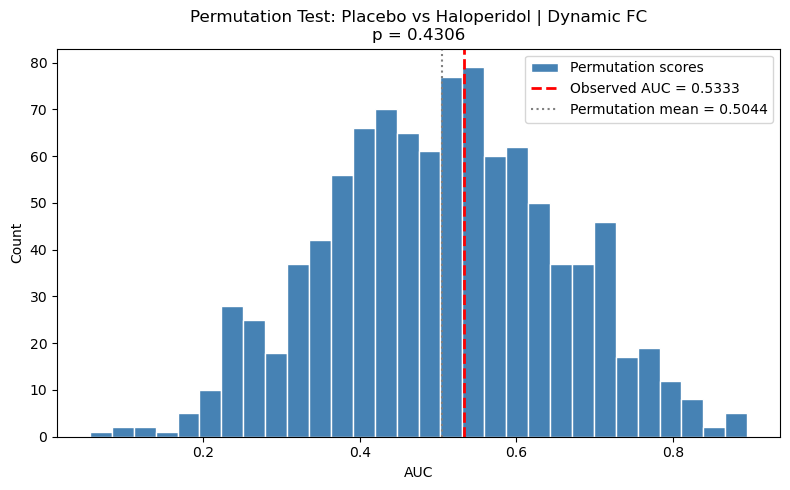

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_ph_dfc.best_params_["clf__C"],
        l1_ratio=grid_ph_dfc.best_params_["clf__l1_ratio"]
    ))
])

score_dfc, perm_scores_dfc, pvalue_ph_dfc = permutation_test_score(
    estimator=best_model_dfc,
    X=X_ph_dfc,
    y=y_ph_dfc_bin,
    cv=cross_validation,
    scoring="roc_auc",              
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_ph_dfc.best_score_)   
print("Observed AUC:           ", score_dfc)                  
print("Permutation p-value:    ", pvalue_ph_dfc)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_dfc, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_dfc, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_dfc:.4f}")                          
plt.axvline(np.mean(perm_scores_dfc), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_dfc):.4f}")
plt.xlabel("AUC")                                             
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Haloperidol | Dynamic FC\np = {pvalue_ph_dfc:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### fALFF

In [ ]:
# -------------------------------------------------
# Placebo vs Haloperidol | X_falff
# -------------------------------------------------
mask_ph = np.isin(y, ["placebo", "haloperidol"])
X_ph_falff = X_falff[mask_ph]
y_ph_falff = y[mask_ph]

print("X_ph_falff shape:", X_ph_falff.shape)
print("y_ph_falff counts:", np.unique(y_ph_falff, return_counts=True))

assert set(np.unique(y_ph_falff)) == {"placebo", "haloperidol"}, "Unexpected labels!"
y_ph_falff_bin = (y_ph_falff == "haloperidol").astype(int)

print("y_ph_falff_bin counts:", np.unique(y_ph_falff_bin, return_counts=True))


param_grid = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    
}



pipe_en_ph_falff = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])

grid_ph_falff = GridSearchCV(
    estimator=pipe_en_ph_falff,
    param_grid=param_grid,
    cv=cross_validation,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_ph_falff.fit(X_ph_falff, y_ph_falff_bin)

print("Best params:", grid_ph_falff.best_params_)
print("Best CV AUC:", grid_ph_falff.best_score_)               

best_idx = grid_ph_falff.best_index_
print("Placebo vs Haloperidol (Elastic Net, X_falff) | AUC:",  
      grid_ph_falff.cv_results_["mean_test_roc_auc"][best_idx],      
      "+/-",
      grid_ph_falff.cv_results_["std_test_roc_auc"][best_idx])       
print("Placebo vs Haloperidol (Elastic Net, X_falff) | Macro F1:",
      grid_ph_falff.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_ph_falff.cv_results_["std_test_f1_macro"][best_idx])

results_df_falff = pd.DataFrame(grid_ph_falff.cv_results_)
print(
    results_df_falff[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_ph_falff shape: (33, 29398)
y_ph_falff counts: (array(['haloperidol', 'placebo'], dtype='<U11'), array([18, 15]))
y_ph_falff_bin counts: (array([0, 1]), array([15, 18]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

Best params: {'clf__C': 0.05, 'clf__l1_ratio': 0.3}
Best CV AUC: 0.7055555555555556
Placebo vs Haloperidol (Elastic Net, X_falff) | AUC: 0.7055555555555556 +/- 0.20757268546966007
Placebo vs Haloperidol (Elastic Net, X_falff) | Macro F1: 0.564047619047619 +/- 0.2102994301945111
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
18          0.10                  0.7           0.705556          0.133333   
11          0.05                  0.3           0.705556          0.207573   
16          0.10                  0.3           0.688889          0.151535   
17          0.10                  0.5           0.666667          0.167590   
10          0.05                  0.1           0.644444          0.152550   
15          0.10                  0.1           0.611111          0.161971   
28          1.00                  0.7           0.611111          0.161971   
29          1.00                  0.9           0.611111          0.161971   
22          0.50   

##### permutation test

In [ ]:
# -------------------------------------------------
# Placebo vs Haloperidol | X_falff | Permutation Test (1000)
# -------------------------------------------------
from sklearn.model_selection import permutation_test_score

pipe_en_ph_falff_perm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_ph_falff.best_params_["clf__C"],
        l1_ratio=grid_ph_falff.best_params_["clf__l1_ratio"]
    ))
])

observed_score, perm_scores, pvalue = permutation_test_score(
    estimator=pipe_en_ph_falff_perm,
    X=X_ph_falff,
    y=y_ph_falff_bin,
    scoring="roc_auc",
    cv=cross_validation,
    n_permutations=1000,
    n_jobs=-1,
    random_state=42
)

print("=" * 55)
print("Placebo vs Haloperidol (Elastic Net, X_falff) | Permutation Test")
print(f"  Observed AUC : {observed_score:.4f}")
print(f"  Permutation AUC (mean ± std): "
      f"{perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
print(f"  p-value      : {pvalue:.4f}")
print("=" * 55)

KeyboardInterrupt: 

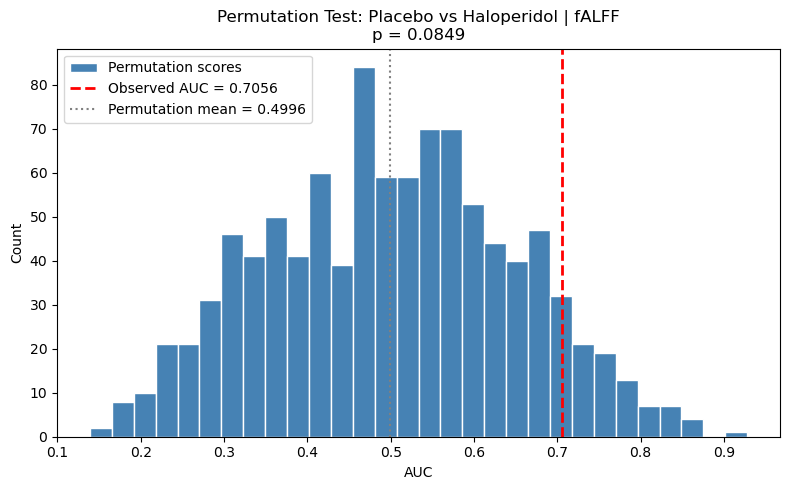

In [ ]:
# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_all, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_all, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_all:.4f}")
plt.axvline(np.mean(perm_scores_all), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_all):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Haloperidol | All Features\np = {pvalue_ph_all:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### Combine

In [60]:
# -------------------------------------------------
# Placebo vs Haloperidol | X_concat_all = static + dynamic + fALFF
# -------------------------------------------------
n_fc    = X_static.shape[1]
n_dfc   = X_dfc_sd.shape[1]
n_falff = X_falff.shape[1]

mask_ph = np.isin(y, ["placebo", "haloperidol"])
X_ph_all = X_concat_all[mask_ph]
y_ph_all = y[mask_ph]

print("X_ph_all shape:", X_ph_all.shape)
print("y_ph_all counts:", np.unique(y_ph_all, return_counts=True))

assert set(np.unique(y_ph_all)) == {"placebo", "haloperidol"}, "Unexpected labels!"
y_ph_all_bin = (y_ph_all == "haloperidol").astype(int)

print("y_ph_all_bin counts:", np.unique(y_ph_all_bin, return_counts=True))

param_grid_all = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

preprocessor = ColumnTransformer([
    ("fc",    StandardScaler(), slice(0, n_fc)),
    ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
    ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
])

pipe_en_ph_all = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        random_state=3344
    ))
])

grid_ph_all = GridSearchCV(
    estimator=pipe_en_ph_all,
    param_grid=param_grid_all,
    cv=cross_validation,
    scoring={
        "roc_auc": "roc_auc",
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",
    n_jobs=-1,
    return_train_score=False
)

grid_ph_all.fit(X_ph_all, y_ph_all_bin)

print("Best params:", grid_ph_all.best_params_)
print("Best CV AUC:", grid_ph_all.best_score_)

best_idx_all = grid_ph_all.best_index_
print("Placebo vs Haloperidol (Elastic Net, X_concat_all) | AUC:",
      grid_ph_all.cv_results_["mean_test_roc_auc"][best_idx_all],
      "+/-",
      grid_ph_all.cv_results_["std_test_roc_auc"][best_idx_all])
print("Placebo vs Haloperidol (Elastic Net, X_concat_all) | Macro F1:",
      grid_ph_all.cv_results_["mean_test_f1_macro"][best_idx_all],
      "+/-",
      grid_ph_all.cv_results_["std_test_f1_macro"][best_idx_all])

results_df_all = pd.DataFrame(grid_ph_all.cv_results_)
print(
    results_df_all[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"
    ]].sort_values("rank_test_roc_auc").head(10)
)



X_ph_all shape: (33, 29778)
y_ph_all counts: (array(['haloperidol', 'placebo'], dtype='<U11'), array([18, 15]))
y_ph_all_bin counts: (array([0, 1]), array([15, 18]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.3}
Best CV AUC: 0.7277777777777777
Placebo vs Haloperidol (Elastic Net, X_concat_all) | AUC: 0.7277777777777777 +/- 0.1365356191938279
Placebo vs Haloperidol (Elastic Net, X_concat_all) | Macro F1: 0.5083333333333333 +/- 0.16716591890826443
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
16          0.10                  0.3           0.727778          0.136536   
18          0.10                  0.7           0.705556          0.133333   
11          0.05                  0.3           0.705556          0.207573   
24          0.50                  0.9           0.694444          0.115202   
17          0.10                  0.5           0.666667          0.167590   
23          0.50                  0.7           0.661111          0.158504   
10          0.05                  0.1           0.661111          0.149485   
15          0.10                  0.1           0.627778          0.162542   
28       

##### permutation test

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_ph_all.best_params_["clf__C"],
        l1_ratio=grid_ph_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

score_all, perm_scores_all, pvalue_ph_all = permutation_test_score(
    estimator=best_model_all,
    X=X_ph_all,
    y=y_ph_all_bin,
    cv=cross_validation,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_ph_all.best_score_)
print("Observed AUC:           ", score_all)
print("Permutation p-value:    ", pvalue_ph_all)



GridSearchCV best AUC:   0.7277777777777777
Observed AUC:            0.7277777777777777
Permutation p-value:     0.06393606393606394


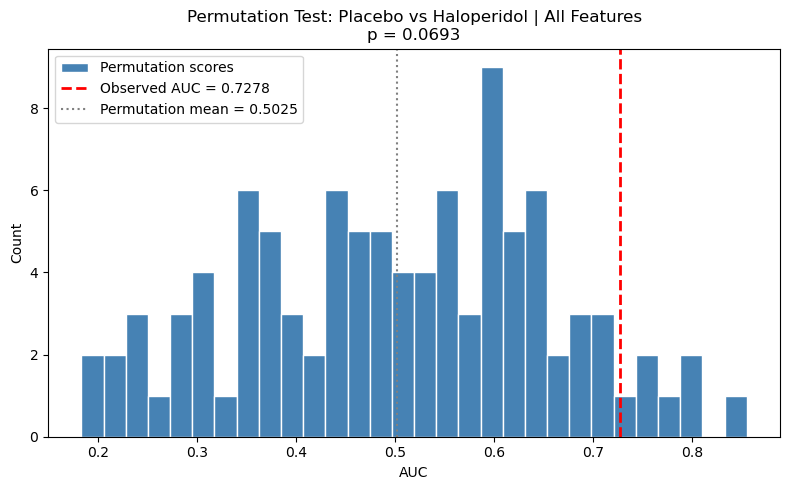

In [ ]:
# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_all, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_all, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_all:.4f}")
plt.axvline(np.mean(perm_scores_all), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_all):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Haloperidol | All Features\np = {pvalue_ph_all:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

### Levodopa vs Placebo

#### FC only

In [ ]:
# -------------------------------------------------
# Placebo vs Levodopa | static FC only (190 features)
# -------------------------------------------------


mask_pl = np.isin(y, ["placebo", "levodopa"])


X_pl_static = X_static[mask_pl]
y_pl_static = y[mask_pl]

print("X_pl_static shape:", X_pl_static.shape)
print("y_pl counts:", np.unique(y_pl_static, return_counts=True))

# placebo = 0, levodopa = 1
assert set(np.unique(y_pl_static)) == {"placebo", "levodopa"}, "Unexpected labels!"
y_pl_bin_static = (y_pl_static == "levodopa").astype(int)

print("y_pl_bin counts:", np.unique(y_pl_bin_static, return_counts=True))


cv_pl = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 4) pipeline
pipe_en_pl_static = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])

# 5) 
param_grid_pl = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],    #
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 6) Grid Search
grid_pl_static = GridSearchCV(
    estimator=pipe_en_pl_static,
    param_grid=param_grid_pl,
    cv=cv_pl,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_pl_static.fit(X_pl_static, y_pl_bin_static)

print("\nBest params:", grid_pl_static.best_params_)
print("Best CV AUC:", grid_pl_static.best_score_)              


best_idx = grid_pl_static.best_index_

print("Placebo vs Levodopa (Elastic Net, static FC) | AUC:",   
      grid_pl_static.cv_results_["mean_test_roc_auc"][best_idx],     
      "+/-",
      grid_pl_static.cv_results_["std_test_roc_auc"][best_idx])      

print("Placebo vs Levodopa (Elastic Net, static FC) | Macro F1:",
      grid_pl_static.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_pl_static.cv_results_["std_test_f1_macro"][best_idx])

results_pl_static = pd.DataFrame(grid_pl_static.cv_results_)
print(
    results_pl_static[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)



X_pl_static shape: (31, 190)
y_pl counts: (array(['levodopa', 'placebo'], dtype='<U11'), array([16, 15]))
y_pl_bin counts: (array([0, 1]), array([15, 16]))

Best params: {'clf__C': 0.05, 'clf__l1_ratio': 0.1}
Best CV AUC: 0.6388888888888888
Placebo vs Levodopa (Elastic Net, static FC) | AUC: 0.6388888888888888 +/- 0.21227747971714223
Placebo vs Levodopa (Elastic Net, static FC) | Macro F1: 0.4614285714285714 +/- 0.15226483671178387
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
10          0.05                  0.1           0.638889          0.212277   
15          0.10                  0.1           0.577778          0.203670   
16          0.10                  0.3           0.577778          0.215452   
17          0.10                  0.5           0.572222          0.198451   
11          0.05                  0.3           0.566667          0.200000   
23          0.50                  0.7           0.561111          0.211111   
29          1.00  

##### Permutation Test

GridSearchCV best AUC:   0.6388888888888888
Observed AUC:            0.6388888888888888
Permutation p-value:     0.1978021978021978


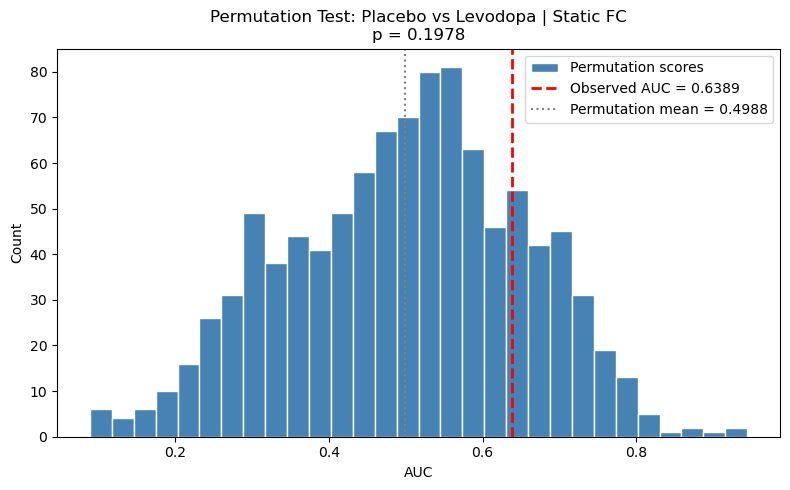

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_pl_static = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_pl_static.best_params_["clf__C"],
        l1_ratio=grid_pl_static.best_params_["clf__l1_ratio"]
    ))
])

score_pl_static, perm_scores_pl_static, pvalue_pl_static = permutation_test_score(
    estimator=best_model_pl_static,
    X=X_pl_static,
    y=y_pl_bin_static,
    cv=cv_pl,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_pl_static.best_score_)
print("Observed AUC:           ", score_pl_static)
print("Permutation p-value:    ", pvalue_pl_static)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_pl_static, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_pl_static, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_pl_static:.4f}")
plt.axvline(np.mean(perm_scores_pl_static), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_pl_static):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Levodopa | Static FC\np = {pvalue_pl_static:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### FC dynamics

In [ ]:
# -------------------------------------------------
# Placebo vs Levodopa | dynamic FC only (190 features)
# -------------------------------------------------


mask_pl = np.isin(y, ["placebo", "levodopa"])


X_pl_dfc = X_dfc_sd[mask_pl]
y_pl_dfc = y[mask_pl]

print("X_pl_dfc shape:", X_pl_dfc.shape)
print("y_pl counts:", np.unique(y_pl_dfc, return_counts=True))

# placebo = 0, levodopa = 1
assert set(np.unique(y_pl_dfc)) == {"placebo", "levodopa"}, "Unexpected labels!"
y_pl_bin_dfc = (y_pl_dfc == "levodopa").astype(int)

print("y_pl_bin counts:", np.unique(y_pl_bin_dfc, return_counts=True))

cv_pl = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 4) pipeline
pipe_en_pl_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


param_grid_pl = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],    
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 6) Grid Search
grid_pl_dfc = GridSearchCV(
    estimator=pipe_en_pl_dfc,
    param_grid=param_grid_pl,
    cv=cv_pl,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_pl_dfc.fit(X_pl_dfc, y_pl_bin_dfc)

print("\nBest params:", grid_pl_dfc.best_params_)
print("Best CV AUC:", grid_pl_dfc.best_score_)                 


best_idx = grid_pl_dfc.best_index_

print("Placebo vs Levodopa (Elastic Net, dynamic FC) | AUC:",  
      grid_pl_dfc.cv_results_["mean_test_roc_auc"][best_idx],        
      "+/-",
      grid_pl_dfc.cv_results_["std_test_roc_auc"][best_idx])         

print("Placebo vs Levodopa (Elastic Net, dynamic FC) | Macro F1:",
      grid_pl_dfc.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_pl_dfc.cv_results_["std_test_f1_macro"][best_idx])

results_pl_dfc = pd.DataFrame(grid_pl_dfc.cv_results_)
print(
    results_pl_dfc[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)



X_pl_dfc shape: (31, 190)
y_pl counts: (array(['levodopa', 'placebo'], dtype='<U11'), array([16, 15]))
y_pl_bin counts: (array([0, 1]), array([15, 16]))

Best params: {'clf__C': 0.05, 'clf__l1_ratio': 0.1}
Best CV AUC: 0.6444444444444445
Placebo vs Levodopa (Elastic Net, dynamic FC) | AUC: 0.6444444444444445 +/- 0.38103173776627214
Placebo vs Levodopa (Elastic Net, dynamic FC) | Macro F1: 0.6914285714285714 +/- 0.33241233307997686
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
10         0.050                  0.1           0.644444          0.381032   
15         0.100                  0.1           0.622222          0.362433   
26         1.000                  0.3           0.594444          0.316033   
21         0.500                  0.3           0.588889          0.332592   
25         1.000                  0.1           0.566667          0.298969   
16         0.100                  0.3           0.566667          0.315054   
20         0.500   

##### Permutation test

GridSearchCV best AUC:   0.6444444444444445
Observed AUC:            0.6444444444444445
Permutation p-value:     0.1878121878121878


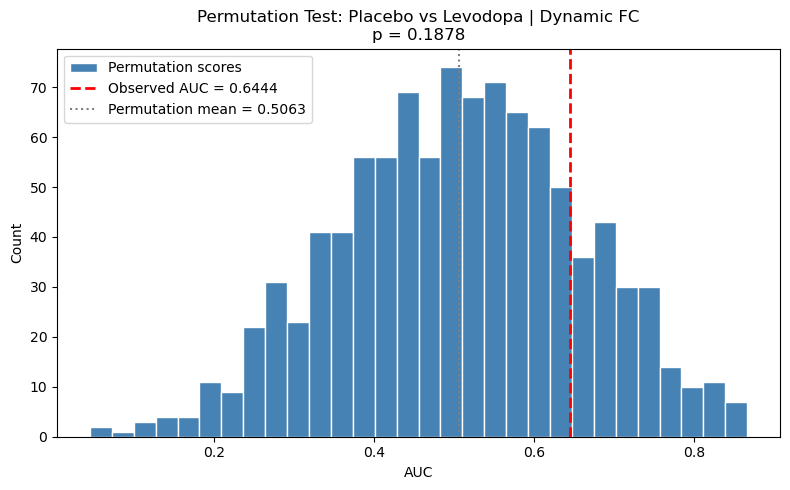

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_pl_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_pl_dfc.best_params_["clf__C"],
        l1_ratio=grid_pl_dfc.best_params_["clf__l1_ratio"]
    ))
])

score_pl_dfc, perm_scores_pl_dfc, pvalue_pl_dfc = permutation_test_score(
    estimator=best_model_pl_dfc,
    X=X_pl_dfc,
    y=y_pl_bin_dfc,
    cv=cv_pl,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_pl_dfc.best_score_)
print("Observed AUC:           ", score_pl_dfc)
print("Permutation p-value:    ", pvalue_pl_dfc)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_pl_dfc, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_pl_dfc, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_pl_dfc:.4f}")
plt.axvline(np.mean(perm_scores_pl_dfc), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_pl_dfc):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Levodopa | Dynamic FC\np = {pvalue_pl_dfc:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### ALFF/fALFF

In [ ]:
# -------------------------------------------------
# Placebo vs Levodopa | fALFF only
# -------------------------------------------------

# 1) 只保留 placebo 和 levodopa
mask_pl = np.isin(y, ["placebo", "levodopa"])

# 2) 直接使用之前算好的 X_falff
X_pl_falff = X_falff[mask_pl]
y_pl_falff = y[mask_pl]

print("X_pl_falff shape:", X_pl_falff.shape)
print("y_pl_falff counts:", np.unique(y_pl_falff, return_counts=True))

# placebo = 0, levodopa = 1
assert set(np.unique(y_pl_falff)) == {"placebo", "levodopa"}, "Unexpected labels!"
y_pl_bin_falff = (y_pl_falff == "levodopa").astype(int)

print("y_pl_bin_falff counts:", np.unique(y_pl_bin_falff, return_counts=True))


cv_pl = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 4) pipeline
pipe_en_pl_falff = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


param_grid_pl_falff = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],    
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 6) Grid Search
grid_pl_falff = GridSearchCV(
    estimator=pipe_en_pl_falff,
    param_grid=param_grid_pl_falff,
    cv=cv_pl,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_pl_falff.fit(X_pl_falff, y_pl_bin_falff)

print("\nBest params:", grid_pl_falff.best_params_)
print("Best CV AUC:", grid_pl_falff.best_score_)               


best_idx = grid_pl_falff.best_index_

print("Placebo vs Levodopa (Elastic Net, fALFF) | AUC:",       
      grid_pl_falff.cv_results_["mean_test_roc_auc"][best_idx],      
      "+/-",
      grid_pl_falff.cv_results_["std_test_roc_auc"][best_idx])       

print("Placebo vs Levodopa (Elastic Net, fALFF) | Macro F1:",
      grid_pl_falff.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_pl_falff.cv_results_["std_test_f1_macro"][best_idx])

results_pl_falff = pd.DataFrame(grid_pl_falff.cv_results_)
print(
    results_pl_falff[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_pl_falff shape: (31, 29398)
y_pl_falff counts: (array(['levodopa', 'placebo'], dtype='<U11'), array([16, 15]))
y_pl_bin_falff counts: (array([0, 1]), array([15, 16]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack


Best params: {'clf__C': 0.5, 'clf__l1_ratio': 0.7}
Best CV AUC: 0.6722222222222223
Placebo vs Levodopa (Elastic Net, fALFF) | AUC: 0.6722222222222223 +/- 0.25843785221362237
Placebo vs Levodopa (Elastic Net, fALFF) | Macro F1: 0.5416666666666666 +/- 0.2713136766016618
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
23           0.5                  0.7           0.672222          0.258438   
28           1.0                  0.7           0.650000          0.262702   
24           0.5                  0.9           0.633333          0.247456   
29           1.0                  0.9           0.633333          0.247456   
22           0.5                  0.5           0.633333          0.247456   
27           1.0                  0.5           0.627778          0.283061   
26           1.0                  0.3           0.627778          0.308121   
21           0.5                  0.3           0.627778          0.283061   
17           0.1            

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


##### permutation test

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

GridSearchCV best AUC:   0.6722222222222223
Observed AUC:            0.6722222222222223
Permutation p-value:     0.14885114885114886


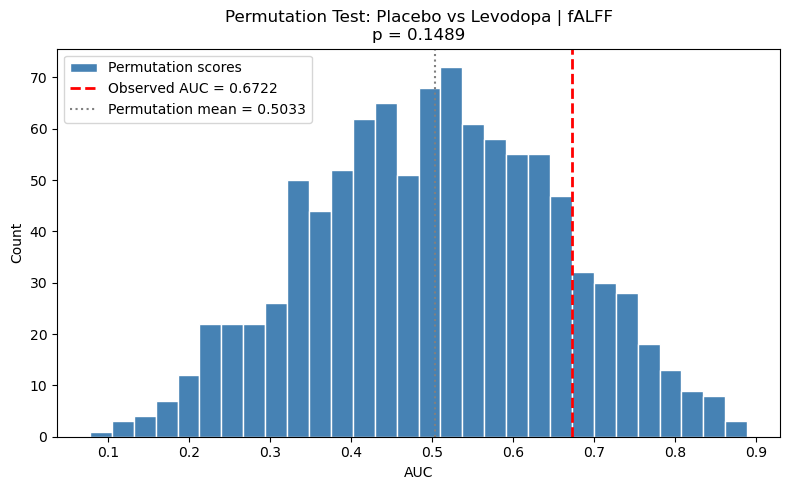

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_pl_falff = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_pl_falff.best_params_["clf__C"],
        l1_ratio=grid_pl_falff.best_params_["clf__l1_ratio"]
    ))
])

score_pl_falff, perm_scores_pl_falff, pvalue_pl_falff = permutation_test_score(
    estimator=best_model_pl_falff,
    X=X_pl_falff,
    y=y_pl_bin_falff,
    cv=cv_pl,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_pl_falff.best_score_)
print("Observed AUC:           ", score_pl_falff)
print("Permutation p-value:    ", pvalue_pl_falff)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_pl_falff, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_pl_falff, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_pl_falff:.4f}")
plt.axvline(np.mean(perm_scores_pl_falff), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_pl_falff):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Levodopa | fALFF\np = {pvalue_pl_falff:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### Levodopa vs Placebo (Combined)

In [ ]:
# -------------------------------------------------
# Placebo vs Levodopa | 380 + fALFF
# -------------------------------------------------


mask_pl = np.isin(y, ["placebo", "levodopa"])


X_pl_all = X_concat_all[mask_pl]
y_pl_all = y[mask_pl]

print("X_pl_all shape:", X_pl_all.shape)
print("y_pl_all counts:", np.unique(y_pl_all, return_counts=True))

# placebo = 0, levodopa = 1
assert set(np.unique(y_pl_all)) == {"placebo", "levodopa"}, "Unexpected labels!"
y_pl_bin_all = (y_pl_all == "levodopa").astype(int)

print("y_pl_bin_all counts:", np.unique(y_pl_bin_all, return_counts=True))


cv_pl = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 4) ColumnTransformer + pipeline
n_fc    = X_static.shape[1]
n_dfc   = X_dfc_sd.shape[1]
n_falff = X_falff.shape[1]

preprocessor = ColumnTransformer([
    ("fc",    StandardScaler(), slice(0, n_fc)),
    ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
    ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
])

pipe_en_pl_all = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        random_state=3344
    ))
])


param_grid_pl_all = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],   
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]       
}

# 6) Grid Search
grid_pl_all = GridSearchCV(
    estimator=pipe_en_pl_all,
    param_grid=param_grid_pl_all,
    cv=cv_pl,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_pl_all.fit(X_pl_all, y_pl_bin_all)

print("\nBest params:", grid_pl_all.best_params_)
print("Best CV AUC:", grid_pl_all.best_score_)                 


best_idx = grid_pl_all.best_index_

print("Placebo vs Levodopa (Elastic Net, all features) | AUC:",  
      grid_pl_all.cv_results_["mean_test_roc_auc"][best_idx],      
      "+/-",
      grid_pl_all.cv_results_["std_test_roc_auc"][best_idx])       

print("Placebo vs Levodopa (Elastic Net, all features) | Macro F1:",
      grid_pl_all.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_pl_all.cv_results_["std_test_f1_macro"][best_idx])

results_pl_all = pd.DataFrame(grid_pl_all.cv_results_)
print(
    results_pl_all[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",          
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)



X_pl_all shape: (31, 29778)
y_pl_all counts: (array(['levodopa', 'placebo'], dtype='<U11'), array([16, 15]))
y_pl_bin_all counts: (array([0, 1]), array([15, 16]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack


Best params: {'clf__C': 0.5, 'clf__l1_ratio': 0.3}
Best CV AUC: 0.6277777777777779
Placebo vs Levodopa (Elastic Net, all features) | AUC: 0.6277777777777779 +/- 0.30812054719693444
Placebo vs Levodopa (Elastic Net, all features) | Macro F1: 0.6019047619047619 +/- 0.27618390796787595
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
27           1.0                  0.5           0.627778          0.308121   
28           1.0                  0.7           0.627778          0.283061   
21           0.5                  0.3           0.627778          0.308121   
23           0.5                  0.7           0.611111          0.258199   
29           1.0                  0.9           0.605556          0.292076   
26           1.0                  0.3           0.605556          0.339025   
22           0.5                  0.5           0.605556          0.292076   
15           0.1                  0.1           0.605556          0.308521   
18           

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


##### permutation test

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

GridSearchCV best AUC:   0.6277777777777779
Observed AUC:            0.6277777777777779
Permutation p-value:     0.23176823176823177


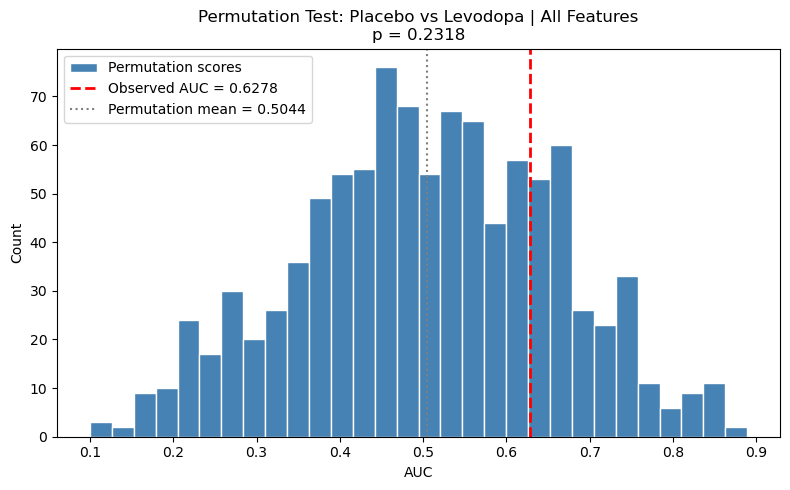

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_pl_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_pl_all.best_params_["clf__C"],
        l1_ratio=grid_pl_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

score_pl_all, perm_scores_pl_all, pvalue_pl_all = permutation_test_score(
    estimator=best_model_pl_all,
    X=X_pl_all,
    y=y_pl_bin_all,
    cv=cv_pl,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_pl_all.best_score_)
print("Observed AUC:           ", score_pl_all)
print("Permutation p-value:    ", pvalue_pl_all)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_pl_all, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_pl_all, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_pl_all:.4f}")
plt.axvline(np.mean(perm_scores_pl_all), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_pl_all):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Placebo vs Levodopa | All Features\np = {pvalue_pl_all:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

### Haloperidol vs Levodopa

#### fc only

In [ ]:
# -------------------------------------------------
# Levodopa vs Haloperidol | static FC only
# -------------------------------------------------


mask_lh = np.isin(y, ["levodopa", "haloperidol"])
X_lh_static = X_static[mask_lh]
y_lh_static = y[mask_lh]

print("X_lh_static shape:", X_lh_static.shape)
print("y_lh_static counts:", np.unique(y_lh_static, return_counts=True))

# levodopa = 0, haloperidol = 1
assert set(np.unique(y_lh_static)) == {"levodopa", "haloperidol"}, "Unexpected labels!"
y_lh_static_bin = (y_lh_static == "haloperidol").astype(int)

print("y_lh_static_bin counts:", np.unique(y_lh_static_bin, return_counts=True))


cv_lh = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 3) pipeline
pipe_en_lh_static = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


param_grid_lh = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],    
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 5) Grid Search
grid_lh_static = GridSearchCV(
    estimator=pipe_en_lh_static,
    param_grid=param_grid_lh,
    cv=cv_lh,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_lh_static.fit(X_lh_static, y_lh_static_bin)

print("Best params:", grid_lh_static.best_params_)
print("Best CV AUC:", grid_lh_static.best_score_)              


best_idx = grid_lh_static.best_index_

print("Levodopa vs Haloperidol (Elastic Net, static FC) | AUC:",  
      grid_lh_static.cv_results_["mean_test_roc_auc"][best_idx],     
      "+/-",
      grid_lh_static.cv_results_["std_test_roc_auc"][best_idx])      

print("Levodopa vs Haloperidol (Elastic Net, static FC) | Macro F1:",
      grid_lh_static.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_lh_static.cv_results_["std_test_f1_macro"][best_idx])

results_lh_static = pd.DataFrame(grid_lh_static.cv_results_)
print(
    results_lh_static[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_lh_static shape: (34, 190)
y_lh_static counts: (array(['haloperidol', 'levodopa'], dtype='<U11'), array([18, 16]))
y_lh_static_bin counts: (array([0, 1]), array([16, 18]))
Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.5}
Best CV AUC: 0.5444444444444445
Levodopa vs Haloperidol (Elastic Net, static FC) | AUC: 0.5444444444444445 +/- 0.08351831321318284
Levodopa vs Haloperidol (Elastic Net, static FC) | Macro F1: 0.5177272727272728 +/- 0.2142719489702243
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
17         0.100                  0.5           0.544444          0.083518   
11         0.050                  0.3           0.533333          0.084984   
16         0.100                  0.3           0.516667          0.133333   
0          0.001                  0.1           0.500000          0.000000   
24         0.500                  0.9           0.500000          0.217307   
23         0.500                  0.7           0.500000          0.17480

##### Permutation test

GridSearchCV best AUC:   0.5444444444444445
Observed AUC:            0.5444444444444445
Permutation p-value:     0.3956043956043956


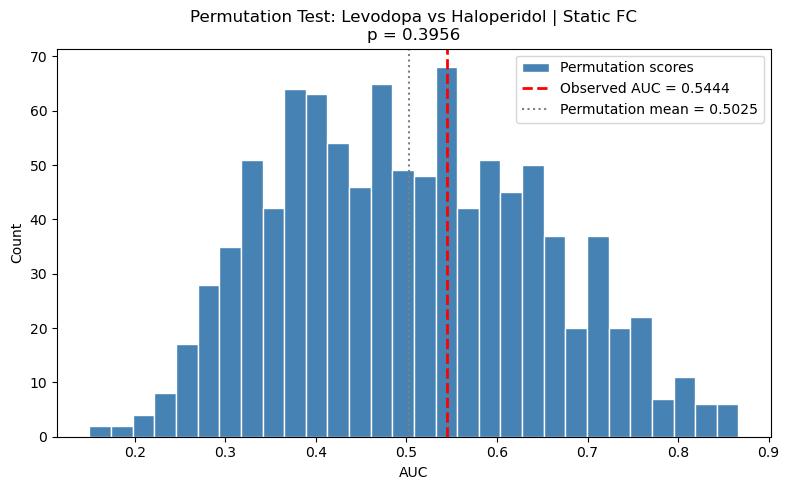

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_lh_static = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_lh_static.best_params_["clf__C"],
        l1_ratio=grid_lh_static.best_params_["clf__l1_ratio"]
    ))
])

score_lh_static, perm_scores_lh_static, pvalue_lh_static = permutation_test_score(
    estimator=best_model_lh_static,
    X=X_lh_static,
    y=y_lh_static_bin,
    cv=cv_lh,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_lh_static.best_score_)
print("Observed AUC:           ", score_lh_static)
print("Permutation p-value:    ", pvalue_lh_static)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_lh_static, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_lh_static, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_lh_static:.4f}")
plt.axvline(np.mean(perm_scores_lh_static), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_lh_static):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Levodopa vs Haloperidol | Static FC\np = {pvalue_lh_static:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### fc dynamic

In [ ]:
# -------------------------------------------------
# Levodopa vs Haloperidol | dynamic FC only
# -------------------------------------------------


mask_lh = np.isin(y, ["levodopa", "haloperidol"])

X_lh_dfc = X_dfc_sd[mask_lh]
y_lh_dfc = y[mask_lh]

print("X_lh_dfc shape:", X_lh_dfc.shape)
print("y_lh_dfc counts:", np.unique(y_lh_dfc, return_counts=True))

# levodopa = 0, haloperidol = 1
assert set(np.unique(y_lh_dfc)) == {"levodopa", "haloperidol"}, "Unexpected labels!"
y_lh_dfc_bin = (y_lh_dfc == "haloperidol").astype(int)

print("y_lh_dfc_bin counts:", np.unique(y_lh_dfc_bin, return_counts=True))


cv_lh = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 3) pipeline
pipe_en_lh_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


param_grid_lh = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],   
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 5) Grid Search
grid_lh_dfc = GridSearchCV(
    estimator=pipe_en_lh_dfc,
    param_grid=param_grid_lh,
    cv=cv_lh,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_lh_dfc.fit(X_lh_dfc, y_lh_dfc_bin)

print("Best params:", grid_lh_dfc.best_params_)
print("Best CV AUC:", grid_lh_dfc.best_score_)                 


best_idx = grid_lh_dfc.best_index_

print("Levodopa vs Haloperidol (Elastic Net, dynamic FC) | AUC:",  
      grid_lh_dfc.cv_results_["mean_test_roc_auc"][best_idx],        
      "+/-",
      grid_lh_dfc.cv_results_["std_test_roc_auc"][best_idx])         

print("Levodopa vs Haloperidol (Elastic Net, dynamic FC) | Macro F1:",
      grid_lh_dfc.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_lh_dfc.cv_results_["std_test_f1_macro"][best_idx])

results_lh_dfc = pd.DataFrame(grid_lh_dfc.cv_results_)
print(
    results_lh_dfc[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_lh_dfc shape: (34, 190)
y_lh_dfc counts: (array(['haloperidol', 'levodopa'], dtype='<U11'), array([18, 16]))
y_lh_dfc_bin counts: (array([0, 1]), array([16, 18]))
Best params: {'clf__C': 0.5, 'clf__l1_ratio': 0.1}
Best CV AUC: 0.5944444444444444
Levodopa vs Haloperidol (Elastic Net, dynamic FC) | AUC: 0.5944444444444444 +/- 0.2747614004195164
Levodopa vs Haloperidol (Elastic Net, dynamic FC) | Macro F1: 0.482063492063492 +/- 0.15263503948441084
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
20          0.50                  0.1           0.594444          0.274761   
10          0.05                  0.1           0.588889          0.195157   
26          1.00                  0.3           0.572222          0.264458   
15          0.10                  0.1           0.572222          0.242543   
21          0.50                  0.3           0.555556          0.295543   
25          1.00                  0.1           0.544444          0.303579   
27 

##### Permutation test

GridSearchCV best AUC:   0.5944444444444444
Observed AUC:            0.5944444444444444
Permutation p-value:     0.24875124875124874


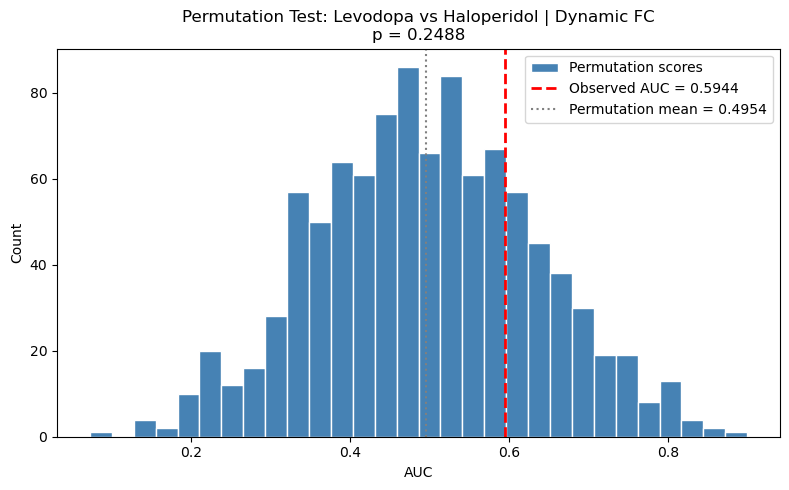

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_lh_dfc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_lh_dfc.best_params_["clf__C"],
        l1_ratio=grid_lh_dfc.best_params_["clf__l1_ratio"]
    ))
])

score_lh_dfc, perm_scores_lh_dfc, pvalue_lh_dfc = permutation_test_score(
    estimator=best_model_lh_dfc,
    X=X_lh_dfc,
    y=y_lh_dfc_bin,
    cv=cv_lh,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_lh_dfc.best_score_)
print("Observed AUC:           ", score_lh_dfc)
print("Permutation p-value:    ", pvalue_lh_dfc)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_lh_dfc, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_lh_dfc, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_lh_dfc:.4f}")
plt.axvline(np.mean(perm_scores_lh_dfc), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_lh_dfc):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Levodopa vs Haloperidol | Dynamic FC\np = {pvalue_lh_dfc:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### ALFF/fALFF

In [ ]:
# -------------------------------------------------
# Levodopa vs Haloperidol | fALFF only
# -------------------------------------------------


mask_lh = np.isin(y, ["levodopa", "haloperidol"])

X_lh_falff = X_falff[mask_lh]
y_lh_falff = y[mask_lh]

print("X_lh_falff shape:", X_lh_falff.shape)
print("y_lh_falff counts:", np.unique(y_lh_falff, return_counts=True))

# levodopa = 0, haloperidol = 1
assert set(np.unique(y_lh_falff)) == {"levodopa", "haloperidol"}, "Unexpected labels!"
y_lh_falff_bin = (y_lh_falff == "haloperidol").astype(int)

print("y_lh_falff_bin counts:", np.unique(y_lh_falff_bin, return_counts=True))


cv_lh = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 3) pipeline
pipe_en_lh_falff = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet"
    ))
])


param_grid_lh_falff = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],  
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 5) Grid Search
grid_lh_falff = GridSearchCV(
    estimator=pipe_en_lh_falff,
    param_grid=param_grid_lh_falff,
    cv=cv_lh,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_lh_falff.fit(X_lh_falff, y_lh_falff_bin)

print("Best params:", grid_lh_falff.best_params_)
print("Best CV AUC:", grid_lh_falff.best_score_)               


best_idx = grid_lh_falff.best_index_

print("Levodopa vs Haloperidol (Elastic Net, fALFF) | AUC:",   
      grid_lh_falff.cv_results_["mean_test_roc_auc"][best_idx],      
      "+/-",
      grid_lh_falff.cv_results_["std_test_roc_auc"][best_idx])       

print("Levodopa vs Haloperidol (Elastic Net, fALFF) | Macro F1:",
      grid_lh_falff.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_lh_falff.cv_results_["std_test_f1_macro"][best_idx])

results_lh_falff = pd.DataFrame(grid_lh_falff.cv_results_)
print(
    results_lh_falff[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)



X_lh_falff shape: (34, 29398)
y_lh_falff counts: (array(['haloperidol', 'levodopa'], dtype='<U11'), array([18, 16]))
y_lh_falff_bin counts: (array([0, 1]), array([16, 18]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.9}
Best CV AUC: 0.8388888888888889
Levodopa vs Haloperidol (Elastic Net, fALFF) | AUC: 0.8388888888888889 +/- 0.18790593916986406
Levodopa vs Haloperidol (Elastic Net, fALFF) | Macro F1: 0.7383333333333333 +/- 0.2284975078881849
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
19          0.10                  0.9           0.838889          0.187906   
18          0.10                  0.7           0.822222          0.183922   
5           0.01                  0.1           0.822222          0.218440   
12          0.05                  0.5           0.822222          0.183922   
17          0.10                  0.5           0.822222          0.183922   
11          0.05                  0.3           0.805556          0.185924   
16          0.10                  0.3           0.755556          0.190354   
24          0.50                  0.9           0.755556          0.190354   
23          0.50     

##### permutation test

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

GridSearchCV best AUC:   0.8388888888888889
Observed AUC:            0.8388888888888889
Permutation p-value:     0.012987012987012988


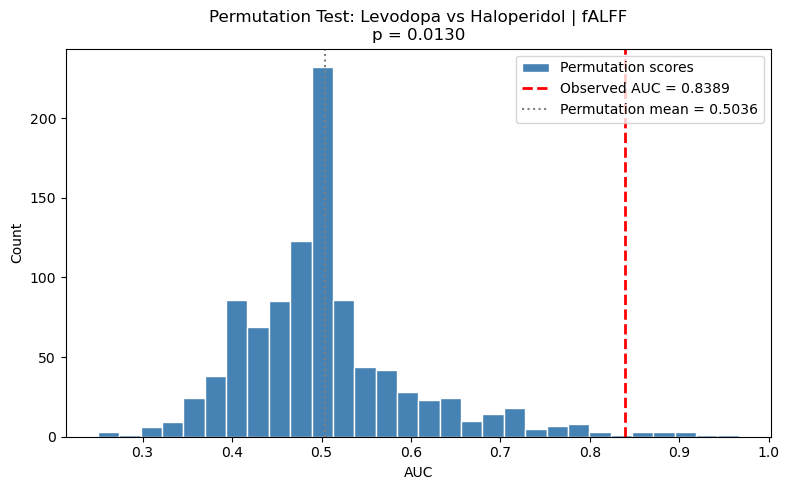

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_lh_falff = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_lh_falff.best_params_["clf__C"],
        l1_ratio=grid_lh_falff.best_params_["clf__l1_ratio"]
    ))
])

score_lh_falff, perm_scores_lh_falff, pvalue_lh_falff = permutation_test_score(
    estimator=best_model_lh_falff,
    X=X_lh_falff,
    y=y_lh_falff_bin,
    cv=cv_lh,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_lh_falff.best_score_)
print("Observed AUC:           ", score_lh_falff)
print("Permutation p-value:    ", pvalue_lh_falff)

# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_lh_falff, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_lh_falff, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_lh_falff:.4f}")
plt.axvline(np.mean(perm_scores_lh_falff), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_lh_falff):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Levodopa vs Haloperidol | fALFF\np = {pvalue_lh_falff:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### Haloperidol vs Levodopa (combined)

In [ ]:
# -------------------------------------------------
# Levodopa vs Haloperidol | static FC + dynamic FC + fALFF
# -------------------------------------------------


mask_lh = np.isin(y, ["levodopa", "haloperidol"])

X_lh_all = X_concat_all[mask_lh]
y_lh_all = y[mask_lh]

print("X_lh_all shape:", X_lh_all.shape)
print("y_lh_all counts:", np.unique(y_lh_all, return_counts=True))

# levodopa = 0, haloperidol = 1
assert set(np.unique(y_lh_all)) == {"levodopa", "haloperidol"}, "Unexpected labels!"
y_lh_all_bin = (y_lh_all == "haloperidol").astype(int)

print("y_lh_all_bin counts:", np.unique(y_lh_all_bin, return_counts=True))


cv_lh = StratifiedKFold(n_splits=5, shuffle=True, random_state=3344)

# 3) ColumnTransformer + pipeline
n_fc    = X_static.shape[1]
n_dfc   = X_dfc_sd.shape[1]
n_falff = X_falff.shape[1]

preprocessor = ColumnTransformer([
    ("fc",    StandardScaler(), slice(0, n_fc)),
    ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
    ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
])

pipe_en_lh_all = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        random_state=3344
    ))
])


param_grid_lh_all = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],    
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]       
}

# 5) Grid Search
grid_lh_all = GridSearchCV(
    estimator=pipe_en_lh_all,
    param_grid=param_grid_lh_all,
    cv=cv_lh,
    scoring={
        "roc_auc": "roc_auc",          
        "f1_macro": "f1_macro"
    },
    refit="roc_auc",                   
    n_jobs=-1,
    return_train_score=False
)

grid_lh_all.fit(X_lh_all, y_lh_all_bin)

print("Best params:", grid_lh_all.best_params_)
print("Best CV AUC:", grid_lh_all.best_score_)                 

best_idx = grid_lh_all.best_index_

print("Levodopa vs Haloperidol (Elastic Net, all features) | AUC:",  
      grid_lh_all.cv_results_["mean_test_roc_auc"][best_idx],          
      "+/-",
      grid_lh_all.cv_results_["std_test_roc_auc"][best_idx])           

print("Levodopa vs Haloperidol (Elastic Net, all features) | Macro F1:",
      grid_lh_all.cv_results_["mean_test_f1_macro"][best_idx],
      "+/-",
      grid_lh_all.cv_results_["std_test_f1_macro"][best_idx])

results_lh_all = pd.DataFrame(grid_lh_all.cv_results_)
print(
    results_lh_all[[
        "param_clf__C",
        "param_clf__l1_ratio",
        "mean_test_roc_auc",           
        "std_test_roc_auc",            
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "rank_test_roc_auc"            
    ]].sort_values("rank_test_roc_auc").head(10)  
)

X_lh_all shape: (34, 29778)
y_lh_all counts: (array(['haloperidol', 'levodopa'], dtype='<U11'), array([18, 16]))
y_lh_all_bin counts: (array([0, 1]), array([16, 18]))


/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.9}
Best CV AUC: 0.8388888888888889
Levodopa vs Haloperidol (Elastic Net, all features) | AUC: 0.8388888888888889 +/- 0.18790593916986406
Levodopa vs Haloperidol (Elastic Net, all features) | Macro F1: 0.7383333333333333 +/- 0.2284975078881849
    param_clf__C  param_clf__l1_ratio  mean_test_roc_auc  std_test_roc_auc  \
19          0.10                  0.9           0.838889          0.187906   
18          0.10                  0.7           0.822222          0.183922   
5           0.01                  0.1           0.822222          0.218440   
12          0.05                  0.5           0.822222          0.183922   
17          0.10                  0.5           0.822222          0.183922   
11          0.05                  0.3           0.805556          0.185924   
16          0.10                  0.3           0.772222          0.199846   
28          1.00                  0.7           0.755556          0.190354   
24     

##### Permutation Test

In [ ]:
# -------------------------------------------------
# Permutation Test
# -------------------------------------------------
best_model_lh_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_lh_all.best_params_["clf__C"],
        l1_ratio=grid_lh_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

score_lh_all, perm_scores_lh_all, pvalue_lh_all = permutation_test_score(
    estimator=best_model_lh_all,
    X=X_lh_all,
    y=y_lh_all_bin,
    cv=cv_lh,
    scoring="roc_auc",
    n_permutations=1000,
    n_jobs=-1,
    random_state=3344
)

print("GridSearchCV best AUC:  ", grid_lh_all.best_score_)
print("Observed AUC:           ", score_lh_all)
print("Permutation p-value:    ", pvalue_lh_all)

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/EfDS2/lib/python3.13/site-pack

GridSearchCV best AUC:   0.8388888888888889
Observed AUC:            0.8388888888888889
Permutation p-value:     0.012987012987012988


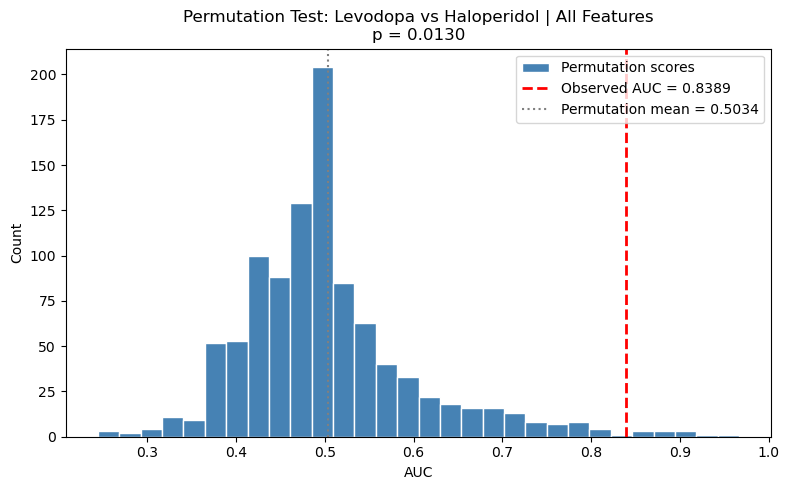

In [ ]:
# -------------------------------------------------
# Permutation Test 
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(perm_scores_lh_all, bins=30, color="steelblue", edgecolor="white", label="Permutation scores")
plt.axvline(score_lh_all, color="red", linestyle="--", linewidth=2, label=f"Observed AUC = {score_lh_all:.4f}")
plt.axvline(np.mean(perm_scores_lh_all), color="gray", linestyle=":", linewidth=1.5, label=f"Permutation mean = {np.mean(perm_scores_lh_all):.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title(f"Permutation Test: Levodopa vs Haloperidol | All Features\np = {pvalue_lh_all:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

# BH correction

In [ ]:
p_values = np.array([
    pvalue_ph_static,   # Placebo vs Haloperidol | static FC
    pvalue_ph_dfc,      # Placebo vs Haloperidol | dynamic FC
    pvalue_ph_falff,    # Placebo vs Haloperidol | fALFF
    pvalue_ph_all,         # Placebo vs Haloperidol | all features
    pvalue_pl_static,   # Placebo vs Levodopa | static FC
    pvalue_pl_dfc,      # Placebo vs Levodopa | dynamic FC
    pvalue_pl_falff,    # Placebo vs Levodopa | fALFF
    pvalue_pl_all,      # Placebo vs Levodopa | all features
    pvalue_lh_static,   # Levodopa vs Haloperidol | static FC
    pvalue_lh_dfc,      # Levodopa vs Haloperidol | dynamic FC
    pvalue_lh_falff,    # Levodopa vs Haloperidol | fALFF
    pvalue_lh_all       # Levodopa vs Haloperidol | all features
])
print(p_values)

[0.15484515 0.43056943 0.08491508 0.06930693 0.1978022  0.18781219
 0.14885115 0.23176823 0.3956044  0.24875125 0.01298701 0.01298701]


In [ ]:

p_values = np.array([
    pvalue_ph_static,   # Placebo vs Haloperidol | static FC
    pvalue_ph_dfc,      # Placebo vs Haloperidol | dynamic FC
    pvalue_ph_falff,    # Placebo vs Haloperidol | fALFF
    pvalue_ph_all,         # Placebo vs Haloperidol | all features
    pvalue_pl_static,   # Placebo vs Levodopa | static FC
    pvalue_pl_dfc,      # Placebo vs Levodopa | dynamic FC
    pvalue_pl_falff,    # Placebo vs Levodopa | fALFF
    pvalue_pl_all,      # Placebo vs Levodopa | all features
    pvalue_lh_static,   # Levodopa vs Haloperidol | static FC
    pvalue_lh_dfc,      # Levodopa vs Haloperidol | dynamic FC
    pvalue_lh_falff,    # Levodopa vs Haloperidol | fALFF
    pvalue_lh_all       # Levodopa vs Haloperidol | all features
])

labels = [
    "PH | static FC",   "PH | dynamic FC",   "PH | fALFF",   "PH | all",
    "PL | static FC",   "PL | dynamic FC",   "PL | fALFF",   "PL | all",
    "LH | static FC",   "LH | dynamic FC",   "LH | fALFF",   "LH | all"
]

# 2) BH FDR 
reject, p_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="fdr_bh"
)


results_fdr = pd.DataFrame({
    "Comparison":       labels,
    "p_original":       p_values,
    "p_corrected_BH":   p_corrected,
    "reject_H0":        reject
})

print(results_fdr.to_string(index=False))

     Comparison  p_original  p_corrected_BH  reject_H0
 PH | static FC    0.154845        0.296703      False
PH | dynamic FC    0.430569        0.430569      False
     PH | fALFF    0.084915        0.254745      False
       PH | all    0.069307        0.254745      False
 PL | static FC    0.197802        0.296703      False
PL | dynamic FC    0.187812        0.296703      False
     PL | fALFF    0.148851        0.296703      False
       PL | all    0.231768        0.298501      False
 LH | static FC    0.395604        0.430569      False
LH | dynamic FC    0.248751        0.298501      False
     LH | fALFF    0.012987        0.077922      False
       LH | all    0.012987        0.077922      False


In [ ]:

pvalues = np.array([
    0.1548, 0.4306, 0.0849, 0.06393,
    0.1978, 0.1878, 0.1488, 0.2317,
    0.3956, 0.2487, 0.0129, 0.013
])

reject, pvals_corrected, alphaSidak, alphaBonf = multipletests(
    pvalues, alpha=0.05, method='fdr_bh'
)

print("BH result (FDR = 0.05)")
print(f"{'#':<4} {'original p':>10} {'after p':>12} {'significant?':>8}")
print("-" * 38)
for i, (p_orig, p_corr, rej) in enumerate(zip(pvalues, pvals_corrected, reject), 1):
    sig = "✓" if rej else ""
    print(f"{i:<4} {p_orig:>10.4f} {p_corr:>12.4f} {sig:>8}")

BH校正结果 (FDR = 0.05)
#          原始 p        校正后 p      显著?
--------------------------------------
1        0.1548       0.2967         
2        0.4306       0.4306         
3        0.0849       0.2547         
4        0.0639       0.2547         
5        0.1978       0.2967         
6        0.1878       0.2967         
7        0.1488       0.2967         
8        0.2317       0.2984         
9        0.3956       0.4306         
10       0.2487       0.2984         
11       0.0129       0.0780         
12       0.0130       0.0780         


# Modality importance

## Haloperidol vs Placebo

In [ ]:
# -------------------------------------------------
# Main analysis: modality importance
# Placebo vs Haloperidol | static FC + dynamic FC + fALFF
# -------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


best_model_ph_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_ph_all.best_params_["clf__C"],
        l1_ratio=grid_ph_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

best_model_ph_all.fit(X_ph_all, y_ph_all_bin)


coefs = best_model_ph_all.named_steps["clf"].coef_.ravel()

print("Total number of coefficients:", len(coefs))
print("Expected number of features:", n_fc + n_dfc + n_falff)


coef_fc    = coefs[0:n_fc]
coef_dfc   = coefs[n_fc:n_fc + n_dfc]
coef_falff = coefs[n_fc + n_dfc:n_fc + n_dfc + n_falff]


def modality_summary(coef_block, modality_name):
    abs_coef = np.abs(coef_block)
    nonzero = coef_block != 0

    return {
        "modality": modality_name,
        "n_features": len(coef_block),
        "sum_abs_beta": abs_coef.sum(),
        "mean_abs_beta": abs_coef.mean(),
        "median_abs_beta": np.median(abs_coef),
        "max_abs_beta": abs_coef.max(),
        "nonzero_count": nonzero.sum(),
        "nonzero_proportion": nonzero.mean()
    }


importance_ph_all = pd.DataFrame([
    modality_summary(coef_fc, "static FC"),
    modality_summary(coef_dfc, "dynamic FC"),
    modality_summary(coef_falff, "fALFF")
])


print("\nPH | all features | Modality importance summary")
print(importance_ph_all)

）
importance_ph_all_sorted = importance_ph_all.sort_values(
    by="mean_abs_beta", ascending=False
).reset_index(drop=True)

print("\nSorted by mean_abs_beta")
print(importance_ph_all_sorted)

Total number of coefficients: 29778
Expected number of features: 29778

PH | all features | Modality importance summary
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0   static FC         190      0.063196       0.000333              0.0   
1  dynamic FC         190      0.111228       0.000585              0.0   
2       fALFF       29398      2.328235       0.000079              0.0   

   max_abs_beta  nonzero_count  nonzero_proportion  
0      0.042901              2            0.010526  
1      0.061761              5            0.026316  
2      0.079668            118            0.004014  

Sorted by mean_abs_beta
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0  dynamic FC         190      0.111228       0.000585              0.0   
1   static FC         190      0.063196       0.000333              0.0   
2       fALFF       29398      2.328235       0.000079              0.0   

   max_abs_beta  nonzero_count  nonzero_p

In [70]:
importance_ph_all["sum_abs_beta_percent"] = (
    importance_ph_all["sum_abs_beta"] / importance_ph_all["sum_abs_beta"].sum()
)

print("\nPercentage contribution based on sum_abs_beta")
print(importance_ph_all[["modality", "sum_abs_beta", "sum_abs_beta_percent"]])


Percentage contribution based on sum_abs_beta
     modality  sum_abs_beta  sum_abs_beta_percent
0   static FC      0.063196              0.025251
1  dynamic FC      0.111228              0.044444
2       fALFF      2.328235              0.930305


In the combined PH classifier, fALFF accounted for most of the total absolute coefficient mass. However, this pattern is likely driven by the much larger dimensionality of the fALFF feature set. On a per-feature basis, dynamic FC showed the largest average coefficient magnitude, followed by static FC, whereas fALFF had the smallest average coefficient magnitude.

## Levodopa vs Placebo

In [ ]:
# -------------------------------------------------
# Main analysis: modality importance
# Placebo vs Levodopa | static FC + dynamic FC + fALFF
# -------------------------------------------------


best_model_pl_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_pl_all.best_params_["clf__C"],
        l1_ratio=grid_pl_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

best_model_pl_all.fit(X_pl_all, y_pl_bin_all)


coefs_pl = best_model_pl_all.named_steps["clf"].coef_.ravel()

print("Total number of coefficients:", len(coefs_pl))
print("Expected number of features:", n_fc + n_dfc + n_falff)


coef_fc_pl    = coefs_pl[0:n_fc]
coef_dfc_pl   = coefs_pl[n_fc:n_fc + n_dfc]
coef_falff_pl = coefs_pl[n_fc + n_dfc:n_fc + n_dfc + n_falff]


def modality_summary(coef_block, modality_name):
    abs_coef = np.abs(coef_block)
    nonzero = coef_block != 0

    return {
        "modality": modality_name,
        "n_features": len(coef_block),
        "sum_abs_beta": abs_coef.sum(),
        "mean_abs_beta": abs_coef.mean(),
        "median_abs_beta": np.median(abs_coef),
        "max_abs_beta": abs_coef.max(),
        "nonzero_count": nonzero.sum(),
        "nonzero_proportion": nonzero.mean()
    }

importance_pl_all = pd.DataFrame([
    modality_summary(coef_fc_pl, "static FC"),
    modality_summary(coef_dfc_pl, "dynamic FC"),
    modality_summary(coef_falff_pl, "fALFF")
])

print("\nPL | all features | Modality importance summary")
print(importance_pl_all)


importance_pl_all_sorted = importance_pl_all.sort_values(
    by="mean_abs_beta", ascending=False
).reset_index(drop=True)

print("\nSorted by mean_abs_beta")
print(importance_pl_all_sorted)


importance_pl_all["sum_abs_beta_percent"] = (
    importance_pl_all["sum_abs_beta"] / importance_pl_all["sum_abs_beta"].sum()
)

print("\nPercentage contribution based on sum_abs_beta")
print(importance_pl_all[["modality", "sum_abs_beta", "sum_abs_beta_percent"]])

Total number of coefficients: 29778
Expected number of features: 29778

PL | all features | Modality importance summary
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0   static FC         190      0.236247       0.001243              0.0   
1  dynamic FC         190      0.126911       0.000668              0.0   
2       fALFF       29398      6.328462       0.000215              0.0   

   max_abs_beta  nonzero_count  nonzero_proportion  
0      0.031795             14            0.073684  
1      0.027493              9            0.047368  
2      0.071540            427            0.014525  

Sorted by mean_abs_beta
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0   static FC         190      0.236247       0.001243              0.0   
1  dynamic FC         190      0.126911       0.000668              0.0   
2       fALFF       29398      6.328462       0.000215              0.0   

   max_abs_beta  nonzero_count  nonzero_p

/opt/anaconda3/envs/EfDS2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In the placebo vs levodopa comparison, static FC showed the largest mean absolute coefficient, followed by dynamic FC and fALFF. Static and dynamic FC also had substantially higher non-zero proportions than fALFF, suggesting that FC-based features were used more efficiently by the classifier. Although fALFF accounted for the majority of the total absolute coefficient mass, this pattern is likely driven by its much larger dimensionality.

## Levodopa vs Haloperidol

In [ ]:
# -------------------------------------------------
# Main analysis: modality importance
# Levodopa vs Haloperidol | static FC + dynamic FC + fALFF
# -------------------------------------------------


best_model_lh_all = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("fc",    StandardScaler(), slice(0, n_fc)),
        ("dfc",   StandardScaler(), slice(n_fc, n_fc + n_dfc)),
        ("falff", StandardScaler(), slice(n_fc + n_dfc, n_fc + n_dfc + n_falff))
    ])),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        C=grid_lh_all.best_params_["clf__C"],
        l1_ratio=grid_lh_all.best_params_["clf__l1_ratio"],
        random_state=3344
    ))
])

best_model_lh_all.fit(X_lh_all, y_lh_all_bin)


coefs_lh = best_model_lh_all.named_steps["clf"].coef_.ravel()

print("Total number of coefficients:", len(coefs_lh))
print("Expected number of features:", n_fc + n_dfc + n_falff)


coef_fc_lh    = coefs_lh[0:n_fc]
coef_dfc_lh   = coefs_lh[n_fc:n_fc + n_dfc]
coef_falff_lh = coefs_lh[n_fc + n_dfc:n_fc + n_dfc + n_falff]


def modality_summary(coef_block, modality_name):
    abs_coef = np.abs(coef_block)
    nonzero = coef_block != 0

    return {
        "modality": modality_name,
        "n_features": len(coef_block),
        "sum_abs_beta": abs_coef.sum(),
        "mean_abs_beta": abs_coef.mean(),
        "median_abs_beta": np.median(abs_coef),
        "max_abs_beta": abs_coef.max(),
        "nonzero_count": nonzero.sum(),
        "nonzero_proportion": nonzero.mean()
    }

importance_lh_all = pd.DataFrame([
    modality_summary(coef_fc_lh, "static FC"),
    modality_summary(coef_dfc_lh, "dynamic FC"),
    modality_summary(coef_falff_lh, "fALFF")
])

print("\nLH | all features | Modality importance summary")
print(importance_lh_all)


importance_lh_all_sorted = importance_lh_all.sort_values(
    by="mean_abs_beta", ascending=False
).reset_index(drop=True)

print("\nSorted by mean_abs_beta")
print(importance_lh_all_sorted)


importance_lh_all["sum_abs_beta_percent"] = (
    importance_lh_all["sum_abs_beta"] / importance_lh_all["sum_abs_beta"].sum()
)

print("\nPercentage contribution based on sum_abs_beta")
print(importance_lh_all[["modality", "sum_abs_beta", "sum_abs_beta_percent"]])

Total number of coefficients: 29778
Expected number of features: 29778

LH | all features | Modality importance summary
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0   static FC         190      0.000000       0.000000              0.0   
1  dynamic FC         190      0.000000       0.000000              0.0   
2       fALFF       29398      0.509397       0.000017              0.0   

   max_abs_beta  nonzero_count  nonzero_proportion  
0      0.000000              0             0.00000  
1      0.000000              0             0.00000  
2      0.122251             10             0.00034  

Sorted by mean_abs_beta
     modality  n_features  sum_abs_beta  mean_abs_beta  median_abs_beta  \
0       fALFF       29398      0.509397       0.000017              0.0   
1   static FC         190      0.000000       0.000000              0.0   
2  dynamic FC         190      0.000000       0.000000              0.0   

   max_abs_beta  nonzero_count  nonzero_p

For the levodopa vs haloperidol comparison, the refitted combined elastic-net model retained only fALFF features, while all static FC and dynamic FC coefficients were shrunk to zero. Specifically, 24 fALFF features had non-zero coefficients, whereas no FC-based features were selected. This suggests that, within the combined classifier, discrimination between levodopa and haloperidol was driven entirely by fALFF-related information.
For the levodopa vs haloperidol comparison, the refitted combined elastic-net model retained only fALFF features, while all static FC and dynamic FC coefficients were shrunk to zero. Specifically, 24 fALFF features had non-zero coefficients, whereas no FC-based features were selected. This suggests that, within the combined classifier, discrimination between levodopa and haloperidol was driven entirely by fALFF-related information.